# Effectiveness Prediction Models — Comprehensive Analysis

**Targets (4 validated + 1 composite):** team_coordination (T1/T3), cooperative (T2),
voice_inclusion (all), mental_demand (all), coord+coop composite (all, within-task centered —
see `analysis/TARGET_INVESTIGATION_LOG.md` §8 for the centering rationale)

**Feature sets:** HMM raw (11), BERT-UMAP (5), Keyword DA (5), NLI DA (5),
Semantic continuity (2), Extra transcript (2), HMM states old K=5 (pre-correction, historical),
HMM states v20260905 (K=5, refit on corrected data), Completion/Repetition (2), Audio (4), combinations

**Models:** Ridge, Lasso, ElasticNet, Random Forest

**CV:** LOGO (10 folds) + L2GO (5 folds, recommended)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', font_scale=1.0)

REPO_ROOT     = Path.cwd() if (Path.cwd() / 'icmi_paper').exists() else Path.cwd().parent
ICMI_RESULTS  = REPO_ROOT / 'icmi_paper' / 'results'
ANALYSIS_RES  = REPO_ROOT / 'analysis' / 'results'
TARGET_PATH   = ANALYSIS_RES / 'perceived_effectiveness_index_participant.tsv'
SELFREPORT_PATH = ANALYSIS_RES / 'collective_features_v20260905' / 'collective_task_selfreport.tsv'

print('Repo root:', REPO_ROOT)

Repo root: c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing


## 1. Load Base Features (HMM input + audio)

In [2]:
HMM_FEATS = [
    'group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean',
    'group_temp_mean_mean', 'group_et_pupil_mean_mean',
    'tr_silence_duration_s', 'tr_backchannel_count', 'tr_laughter_count',
    'tr_n_active_speakers', 'tr_ovl_count', 'tr_ovl_contested',
    'tr_ovl_time_s',
    # tr_ovl_collaboration_index excluded -- derived from deprecated context labels
]
AUDIO_FEATS = ['audio_energy_mean', 'audio_pitch_mean', 'audio_pitch_sd', 'audio_hnr_mean']

KEY = ['group_id', 'task_id', 'window_index']
# Corrected v20260905 pipeline has complete window coverage for all 30 group-task combos,
# including grp-09/T1, grp-12/T3, grp-13/T3 which are entirely absent from the older
# icmi_paper/results HMM feature file (that file silently dropped these 3 sessions).
hmm_win = pd.read_csv(ANALYSIS_RES / 'collective_features_v20260905' / 'collective_window_features.tsv', sep='\t')
hmm_win['tr_ovl_contested'] = hmm_win['tr_ovl_competitive_timing'] + hmm_win['tr_ovl_floor_fight']
audio_win = pd.read_csv(ICMI_RESULTS / 'audio_window_features.tsv', sep='\t')
# Left merge -- keep sessions with no audio match (grp-09/T1, grp-13/T3) instead of dropping them;
# their non-audio HMM_FEATS still contribute, audio-only feature sets skip them via run_cv's NaN mask.
merged = hmm_win[KEY + [c for c in HMM_FEATS if c in hmm_win.columns]].merge(
    audio_win[KEY + AUDIO_FEATS], on=KEY, how='left')
merged = merged[merged['task_id'].isin(['T1','T2','T3'])].reset_index(drop=True)

PHYSIO_Z = ['group_hr_mean_bpm_mean','group_eda_phasic_rate_hz_mean','group_temp_mean_mean','group_et_pupil_mean_mean']
LOG_FEATS = ['tr_silence_duration_s','tr_backchannel_count','tr_laughter_count','tr_ovl_count','tr_ovl_contested','tr_ovl_time_s']
clean = merged.copy()
for col in PHYSIO_Z + AUDIO_FEATS:
    clean[col] = clean.groupby('group_id')[col].transform(lambda x: (x - x.mean())/(x.std(ddof=1)+1e-9))
for col in LOG_FEATS:
    clean[col] = np.log1p(clean[col].clip(lower=0))

feat_task = clean.groupby(['group_id','task_id'])[HMM_FEATS+AUDIO_FEATS].mean().reset_index().rename(columns={'task_id':'task'})
print(f'Base feature table: {feat_task.shape}  ({len(HMM_FEATS)} HMM + {len(AUDIO_FEATS)} audio)')


Base feature table: (30, 17)  (11 HMM + 4 audio)


## 2. Load NLP + New Features

In [3]:
BERT_FEATS     = [f'bert_umap{i+1}' for i in range(5)]
KW_FEATS       = ['da_hedge','da_question','da_backchannel','da_statement','da_agreement']
NLI_FEATS_RAW  = ['da_disagreement','da_compromise','da_hedge','da_backchannel','da_offtask']
SEM_FEATS      = ['tr_semantic_continuity','tr_cross_speaker_similarity']
EXTRA_TR_FEATS = ['tr_speaking_entropy','tr_spk_count']
CR_FEATS       = ['n_completions','n_repetitions']

OVL_TIMING_FEATS = [
    'tr_ovl_simultaneous', 'tr_ovl_smooth',
    'tr_ovl_competitive_timing', 'tr_ovl_floor_fight',
    'tr_conflict_overlap_ratio',
]
RICH_PHYSIO_FEATS = [
    'group_hrv_rmssd_ms_mean',
    'group_et_blink_rate_per_min_mean',
    'group_et_gaze_dispersion_mean',
]

# Theory-driven subset of lexical features (avoid redundancy with HMM/overlap features)
LEX_KEY_FEATS = [
    'lex_ttr',             # vocabulary diversity
    'lex_vader_compound',  # overall sentiment
    'lex_we_i_ratio',      # collective framing (we vs I)
    'lex_word_gini',       # participation inequality
    'lex_turn_cohesion',   # Jaccard between consecutive turns (lexical entrainment)
    'lex_dm_elaboration',  # elaboration discourse markers
    'lex_dm_contrast',     # contrast/disagreement markers
    'lex_hedging_count',   # hedging/uncertainty
    'lex_social_composite',# social language composite
    'lex_subordination_ratio', # syntactic complexity
]

def load_window_agg(fpath, feats, key=KEY):
    df = pd.read_csv(fpath, sep='\t')
    avail = [c for c in feats if c in df.columns]
    return (df.groupby(key[:2])[avail].mean().reset_index()
              .rename(columns={'task_id':'task'})), avail

bert_win2 = pd.read_csv(ANALYSIS_RES/'bert_embeddings_window_30s.tsv', sep='\t')
bert_task = (bert_win2[bert_win2['bert_valid']].groupby(['group_id','task_id'])[BERT_FEATS]
             .mean().reset_index().rename(columns={'task_id':'task'}))

kw_task,  KW_FEATS        = load_window_agg(ANALYSIS_RES/'da_keyword_window_30s.tsv',        KW_FEATS)

nli_win = pd.read_csv(ANALYSIS_RES/'da_window_30s.tsv', sep='\t')
NLI_FEATS = [c for c in NLI_FEATS_RAW if c in nli_win.columns]
nli_task = nli_win.groupby(['group_id','task_id'])[NLI_FEATS].mean().reset_index().rename(columns={'task_id':'task'})
nli_task = nli_task.rename(columns={c:f'nli_{c}' for c in NLI_FEATS})
NLI_FEATS = [f'nli_{c}' for c in NLI_FEATS]

sem_task, SEM_FEATS       = load_window_agg(ANALYSIS_RES/'semantic_continuity_window_30s.tsv', SEM_FEATS)

coll_win = pd.read_csv(ANALYSIS_RES/'collective_features_v20260905'/'collective_window_features.tsv', sep='\t')
EXTRA_TR_FEATS    = [c for c in EXTRA_TR_FEATS    if c in coll_win.columns]
OVL_TIMING_FEATS  = [c for c in OVL_TIMING_FEATS  if c in coll_win.columns]
RICH_PHYSIO_FEATS = [c for c in RICH_PHYSIO_FEATS if c in coll_win.columns]
all_coll_feats = list(dict.fromkeys(EXTRA_TR_FEATS + OVL_TIMING_FEATS + RICH_PHYSIO_FEATS))
coll_task = coll_win.groupby(['group_id','task_id'])[all_coll_feats].mean().reset_index().rename(columns={'task_id':'task'})

# Lexical features
lex_win = pd.read_csv(ANALYSIS_RES/'lexical_window_30s.tsv', sep='\t')
ALL_LEX_FEATS = [c for c in lex_win.columns if c.startswith('lex_')]
LEX_KEY_FEATS = [c for c in LEX_KEY_FEATS if c in lex_win.columns]
lex_task = lex_win.groupby(['group_id','task_id'])[ALL_LEX_FEATS].mean().reset_index().rename(columns={'task_id':'task'})

cr_path = ANALYSIS_RES / 'completion_repetition_task.tsv'
if cr_path.exists():
    cr_task = pd.read_csv(cr_path, sep='\t')
    cr_task.columns = cr_task.columns.str.strip()
    if 'task_id' in cr_task.columns:
        cr_task = cr_task.rename(columns={'task_id':'task'})
    CR_FEATS = [c for c in CR_FEATS if c in cr_task.columns]
else:
    cr_task = pd.DataFrame(columns=['group_id','task'])
    CR_FEATS = []

print('BERT:', len(BERT_FEATS), ' KwDA:', len(KW_FEATS), ' NLI DA:', len(NLI_FEATS),
      ' Sem:', len(SEM_FEATS), ' OvlTiming:', len(OVL_TIMING_FEATS),
      ' RichPhysio:', len(RICH_PHYSIO_FEATS), ' Lexical:', len(ALL_LEX_FEATS), ' CR:', len(CR_FEATS))

BERT: 5  KwDA: 5  NLI DA: 5  Sem: 2  OvlTiming: 5  RichPhysio: 3  Lexical: 37  CR: 2


## 3. Load HMM State Proportions

Old HMM states are aggregated from the window-level `hmm_cluster_assignments_k5_updated_overlaps.tsv`
assignments (the actual source of the validated `S1_pct` -> coord+coop composite benchmark, R^2=0.297,
in `TARGET_INVESTIGATION_LOG.md` \u00a78) -- NOT `hmm_prediction_results.tsv`, which is a later, different
5-state re-run whose S*_pct columns do not carry the same signal (verified: best single-feature L2GO R^2
there is only 0.124, vs 0.332 from the true original source).

In [4]:
old_hmm_win = pd.read_csv(ICMI_RESULTS / 'hmm_cluster_assignments_k5_updated_overlaps.tsv', sep='\t')
old_hmm = (old_hmm_win.groupby(['group_id','task_id'])['hmm_state']
           .value_counts(normalize=True).unstack(fill_value=0))
old_hmm.columns = [f'old_S{c}_pct' for c in old_hmm.columns]
old_hmm = old_hmm.reset_index().rename(columns={'task_id':'task'})
HMM_OLD_FEATS = [c for c in old_hmm.columns if c.startswith('old_') and c.endswith('_pct')]

# Refit 2026-09-05 on corrected collective_features_v20260905 (see docs/hmm_state_interpretation.md §6a)
new_hmm_path = ANALYSIS_RES / 'hmm_states_v20260905' / 'hmm_state_proportions_task.tsv'
if new_hmm_path.exists():
    new_hmm = pd.read_csv(new_hmm_path, sep='\t')
    if 'task_id' in new_hmm.columns:
        new_hmm = new_hmm.rename(columns={'task_id':'task'})
    new_hmm = new_hmm.rename(columns={c: f'new_{c}' for c in new_hmm.columns if c.endswith('_pct')})
    HMM_NEW_FEATS = [c for c in new_hmm.columns if c.startswith('new_') and c.endswith('_pct')]
    print(f'Old HMM states (pre-correction): {HMM_OLD_FEATS}  |  New HMM states (v20260905): {HMM_NEW_FEATS}')
else:
    new_hmm = pd.DataFrame(columns=['group_id','task'])
    HMM_NEW_FEATS = []
    print('New HMM state file not found')

# K-Means clusters (no temporal/Markov structure) -- v20260905 ablation, see hmm_collective_states_updated_overlaps.ipynb Sec.11
kmeans_path = ANALYSIS_RES / 'hmm_states_v20260905' / 'kmeans_state_proportions_task.tsv'
if kmeans_path.exists():
    kmeans_task = pd.read_csv(kmeans_path, sep='\t')
    if 'task_id' in kmeans_task.columns:
        kmeans_task = kmeans_task.rename(columns={'task_id':'task'})
    kmeans_task = kmeans_task.rename(columns={c: f'km_{c}' for c in kmeans_task.columns if c.endswith('_pct')})
    KMEANS_FEATS = [c for c in kmeans_task.columns if c.startswith('km_') and c.endswith('_pct')]
else:
    kmeans_task = pd.DataFrame(columns=['group_id','task'])
    KMEANS_FEATS = []

# Continuous PCA summary (no discretization at all) -- same Sec.11 comparison
pca_cont_path = ANALYSIS_RES / 'hmm_states_v20260905' / 'pca_continuous_features_task.tsv'
if pca_cont_path.exists():
    pca_task = pd.read_csv(pca_cont_path, sep='\t')
    if 'task_id' in pca_task.columns:
        pca_task = pca_task.rename(columns={'task_id':'task'})
    PCA_CONT_FEATS = [c for c in pca_task.columns if c.startswith('PC')]
else:
    pca_task = pd.DataFrame(columns=['group_id','task'])
    PCA_CONT_FEATS = []

print(f'K-Means clusters: {KMEANS_FEATS}  |  Continuous PCA: {len(PCA_CONT_FEATS)} cols')


Old HMM states (pre-correction): ['old_S0_pct', 'old_S1_pct', 'old_S2_pct', 'old_S3_pct']  |  New HMM states (v20260905): ['new_S0_pct', 'new_S1_pct', 'new_S2_pct', 'new_S3_pct', 'new_S4_pct', 'new_S5_pct']
K-Means clusters: ['km_S0_pct', 'km_S1_pct', 'km_S2_pct', 'km_S3_pct', 'km_S4_pct', 'km_S5_pct']  |  Continuous PCA: 12 cols


## 4. Load Outcomes

In [5]:
sr = pd.read_csv(SELFREPORT_PATH, sep='\t').rename(columns={'task_id': 'task'})
SR_OUTCOMES = ['team_coordination_mean', 'cooperative_mean', 'voice_inclusion_mean', 'mental_demand_mean',
               'satisfaction_mean', 'decision_confidence_mean', 'idea_quality_mean']
target_task = sr[['group_id', 'task']].drop_duplicates()

model_df = feat_task.merge(target_task, on=['group_id','task'], how='inner')
dropped = set(zip(target_task['group_id'],target_task['task'])) - set(zip(model_df['group_id'],model_df['task']))

task_dummies = pd.get_dummies(model_df['task'], prefix='task', drop_first=True)
model_df = pd.concat([model_df, task_dummies], axis=1)
TASK_DUMMY_COLS = list(task_dummies.columns)

for df_extra in [bert_task, kw_task, nli_task, sem_task, coll_task, lex_task, cr_task,
                 old_hmm[['group_id','task']+HMM_OLD_FEATS],
                 (new_hmm[['group_id','task']+HMM_NEW_FEATS] if HMM_NEW_FEATS else None),
                 (kmeans_task[['group_id','task']+KMEANS_FEATS] if KMEANS_FEATS else None),
                 (pca_task[['group_id','task']+PCA_CONT_FEATS] if PCA_CONT_FEATS else None),
                 sr[['group_id','task']+SR_OUTCOMES]]:
    if df_extra is None or df_extra.empty:
        continue
    model_df = model_df.merge(df_extra, on=['group_id','task'], how='left')

# Within-task centering only (no std division, per task separately) -- NOT pooled z-scoring
model_df['_coord_coop_centered'] = np.nan
for col, tasks in [('team_coordination_mean', ['T1','T3']), ('cooperative_mean', ['T2'])]:
    if col not in model_df.columns:
        continue
    for t in tasks:
        mask = model_df['task'] == t
        vals = model_df.loc[mask, col]
        model_df.loc[mask, '_coord_coop_centered'] = vals - vals.mean()

print(f'Modeling table: {model_df.shape}  ({len(dropped)} missing)')


Modeling table: (30, 121)  (0 missing)


## 5. Build Modeling Table

In [6]:
TARGET_TASKS = {
    'cooperative':           (['T2'],          'cooperative_mean'),
    'team_coord':            (['T1','T3'],     'team_coordination_mean'),
    'voice_inclusion':       (['T1','T2','T3'],'voice_inclusion_mean'),
    'mental_demand':         (['T1','T2','T3'],'mental_demand_mean'),
    'coord+coop (centered)': (['T1','T2','T3'],'_coord_coop_centered'),
}

# Sub-modality groups for incremental analysis
PHYSIO     = ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean']
ET         = ['group_et_pupil_mean_mean'] + RICH_PHYSIO_FEATS  # pupil + HRV + blink + gaze
TR_BASIC   = ['tr_silence_duration_s', 'tr_backchannel_count', 'tr_laughter_count',
              'tr_n_active_speakers', 'tr_ovl_count', 'tr_ovl_time_s']
TR_FULL    = TR_BASIC + EXTRA_TR_FEATS + OVL_TIMING_FEATS  # + entropy + timing overlaps

MODALITY_SETS = {
    # -- Incremental builds --
    '1. Physio':                  PHYSIO,
    '2. Physio+ET':               PHYSIO + ET,
    '3. Physio+ET+Audio':         PHYSIO + ET + AUDIO_FEATS,
    '4. Physio+ET+Transcript':    PHYSIO + ET + TR_BASIC,
    '5. +OvlTiming+Entropy':      PHYSIO + ET + TR_FULL,
    '6. +Audio+Transcript (all)': PHYSIO + ET + AUDIO_FEATS + TR_FULL,
    '7. +Lexical':                PHYSIO + ET + AUDIO_FEATS + TR_FULL + LEX_KEY_FEATS,
    '8. +NLP (BERT+DA+Sem)':      PHYSIO + ET + AUDIO_FEATS + TR_FULL + LEX_KEY_FEATS + BERT_FEATS + NLI_FEATS + SEM_FEATS,
    # -- Individual modalities --
    'Physio only':         PHYSIO,
    'ET only':             ET,
    'Audio only':          AUDIO_FEATS,
    'Transcript basic':    TR_BASIC,
    'Overlap timing':      OVL_TIMING_FEATS,
    'Lexical key (10)':    LEX_KEY_FEATS,
    'BERT-UMAP (5)':       BERT_FEATS,
    'NLI DA (5)':          NLI_FEATS,
    'Semantic (2)':        SEM_FEATS,
    'Keyword DA (5)':      KW_FEATS,
    # -- HMM-based --
    'HMM raw (11)':                       HMM_FEATS,
    'HMM states old K5 (pre-correction)': HMM_OLD_FEATS,
    'HMM states v20260905 (K5)':          HMM_NEW_FEATS,
}

print(f'{len(TARGET_TASKS)} targets x {len(MODALITY_SETS)} feature sets')

5 targets x 21 feature sets


## 6. CV Functions

In [7]:
LOGO  = LeaveOneGroupOut()
L2GO  = GroupKFold(n_splits=5)

def run_cv(feature_cols, target_col, task_filter, cv, model='ridge', use_pca=False):
    df = model_df[model_df['task'].isin(task_filter)].copy()
    if target_col not in df.columns or df[target_col].isna().all():
        return np.nan
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    avail_feats = [c for c in feature_cols if c in df.columns]
    if not avail_feats:
        return np.nan
    cols = avail_feats + task_cols
    X = df[cols].values.astype(float)
    y = df[target_col].values.astype(float)
    g = df['group_id'].values
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    if mask.sum() < len(np.unique(g[mask])):
        return np.nan
    X_m, y_m, g_m = X[mask], y[mask], g[mask]
    n_pca = min(2, len(avail_feats), X_m.shape[0]-1)

    if model == 'ridge':
        pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
    elif model == 'lasso':
        pipe = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=10000, random_state=42))
    elif model == 'enet':
        pipe = make_pipeline(StandardScaler(), ElasticNetCV(cv=5, l1_ratio=[0.1,0.5,0.9,1.0], max_iter=10000, random_state=42))
    elif model == 'rf':
        pipe = RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42)
    else:
        raise ValueError(f'Unknown model: {model}')

    if use_pca and n_pca >= 1 and model != 'rf':
        pipe = make_pipeline(StandardScaler(), PCA(n_components=n_pca), pipe.steps[-1][1])

    try:
        preds = cross_val_predict(pipe, X_m, y_m, cv=cv, groups=g_m)
        return round(float(r2_score(y_m, preds)), 3)
    except Exception:
        return np.nan

print('CV functions ready')

CV functions ready


## 7. Define Targets and Feature Sets

In [8]:
TARGET_TASKS = {
    'cooperative':           (['T2'],          'cooperative_mean'),
    'team_coord':            (['T1','T3'],     'team_coordination_mean'),
    'voice_inclusion':       (['T1','T2','T3'],'voice_inclusion_mean'),
    'mental_demand':         (['T1','T2','T3'],'mental_demand_mean'),
    'coord+coop (centered)': (['T1','T2','T3'],'_coord_coop_centered'),
}

MODALITY_SETS = {
    'HMM raw (12)':      HMM_FEATS,
    'Audio (4)':         AUDIO_FEATS,
    'BERT-UMAP (5)':     BERT_FEATS,
    'Keyword DA (5)':    KW_FEATS,
    'NLI DA (5)':        NLI_FEATS,
    'Semantic (2)':      SEM_FEATS,
    'Extra TR (2)':      EXTRA_TR_FEATS,
    'HMM states old K5 (pre-correction)': HMM_OLD_FEATS,
    'HMM states v20260905 (K5)':          HMM_NEW_FEATS,
    'HMM+BERT':          HMM_FEATS + BERT_FEATS,
    'HMM+NLI DA':        HMM_FEATS + NLI_FEATS,
    'HMM+ExtraTR':       HMM_FEATS + EXTRA_TR_FEATS,
    'HMM+Semantic':      HMM_FEATS + SEM_FEATS,
    'All NLP':           BERT_FEATS + KW_FEATS + SEM_FEATS + EXTRA_TR_FEATS,
    'All raw':           HMM_FEATS + AUDIO_FEATS + BERT_FEATS + KW_FEATS + SEM_FEATS + EXTRA_TR_FEATS,
}

print(f'{len(TARGET_TASKS)} targets × {len(MODALITY_SETS)} feature sets')

5 targets × 15 feature sets


## 8. Section 1: Feature-Set Comparison (Ridge, L2GO)

Primary analysis — which feature sets predict which outcomes under L2GO?

In [9]:
rows = []
for t_name, (tasks, t_col) in TARGET_TASKS.items():
    for m_name, feats in MODALITY_SETS.items():
        if not feats:
            continue
        r2_logo = run_cv(feats, t_col, tasks, LOGO, 'ridge', False)
        r2_l2go = run_cv(feats, t_col, tasks, L2GO, 'ridge', False)
        r2_pca  = run_cv(feats, t_col, tasks, L2GO, 'ridge', True)
        rows.append({'Target': t_name, 'Feature set': m_name,
                     'LOGO': r2_logo, 'L2GO_raw': r2_l2go, 'L2GO_PCA2': r2_pca})

feat_df = pd.DataFrame(rows)

print('=== L2GO Raw — Ridge ===')
print(feat_df.pivot(index='Feature set', columns='Target', values='L2GO_raw').round(3).to_string())
print()
print('=== L2GO PCA-2 — Ridge ===')
print(feat_df.pivot(index='Feature set', columns='Target', values='L2GO_PCA2').round(3).to_string())

=== L2GO Raw — Ridge ===
Target                              cooperative  coord+coop (centered)  mental_demand  team_coord  voice_inclusion
Feature set                                                                                                       
All NLP                                  -1.316                 -0.242          0.056      -1.949            0.113
All raw                                  -1.444                 -0.190         -1.086      -0.467            0.345
Audio (4)                                -0.073                 -0.066          0.206      -0.241            0.493
BERT-UMAP (5)                            -2.372                 -0.189          0.145      -0.235            0.299
Extra TR (2)                             -0.926                 -0.119          0.233      -0.022            0.252
HMM raw (12)                             -0.491                 -0.066          0.185       0.290            0.234
HMM states old K5 (pre-correction)       -0.472        

## 9. Section 2: Model Comparison (HMM raw, L2GO)

Ridge vs Lasso vs ElasticNet vs Random Forest — all on HMM raw features.

In [10]:
model_rows = []
for t_name, (tasks, t_col) in TARGET_TASKS.items():
    for mdl in ['ridge', 'lasso', 'enet', 'rf']:
        r2 = run_cv(HMM_FEATS, t_col, tasks, L2GO, mdl, False)
        model_rows.append({'Model': mdl.upper().replace('ENET','ElasticNet'),
                           'Target': t_name, 'L2GO_R2': r2})

model_comp = pd.DataFrame(model_rows)
print('=== Model comparison on HMM raw features (L2GO) ===')
print(model_comp.pivot(index='Model', columns='Target', values='L2GO_R2').round(3).to_string())

=== Model comparison on HMM raw features (L2GO) ===
Target      cooperative  coord+coop (centered)  mental_demand  team_coord  voice_inclusion
Model                                                                                     
ElasticNet       -0.894                 -0.175          0.077       0.132            0.295
LASSO            -0.990                 -0.170          0.107       0.142            0.386
RF               -0.092                 -0.046          0.108       0.149            0.166
RIDGE            -0.491                 -0.066          0.185       0.290            0.234


## 10. Heatmap Visualisation

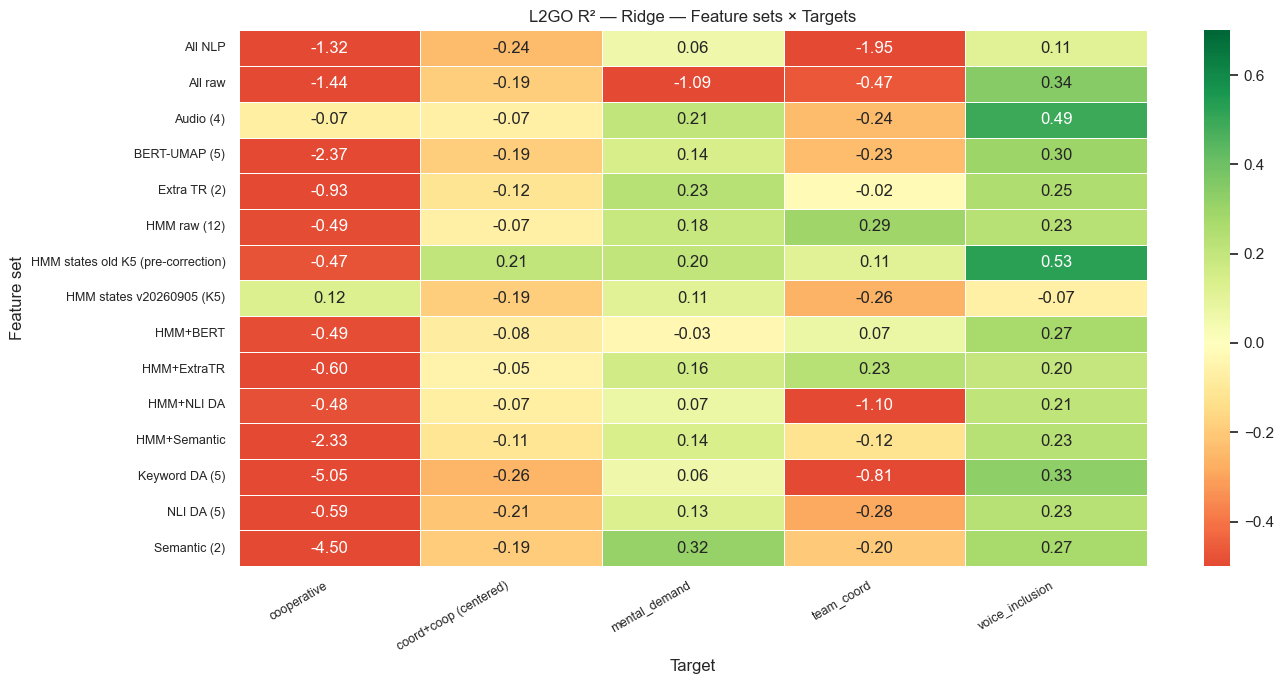

In [11]:
pivot = feat_df.pivot(index='Feature set', columns='Target', values='L2GO_raw')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.7,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax)
ax.set_title('L2GO R² — Ridge — Feature sets × Targets', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 11. Feature Importance (Random Forest on HMM features)

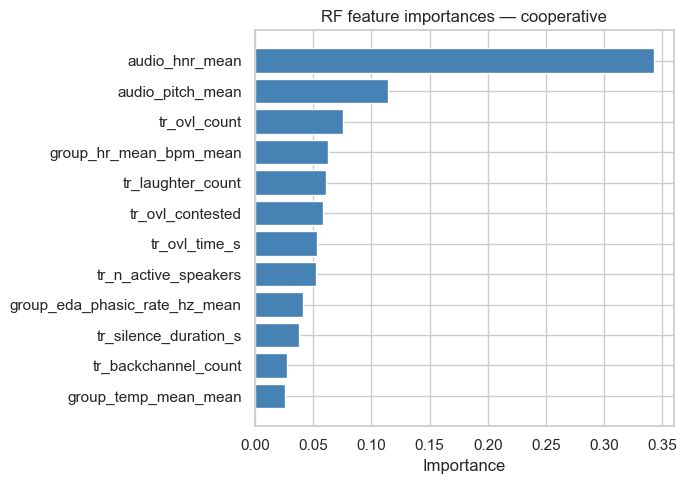

In [12]:
# Fit RF on cooperative (best target) to get feature importances
best_target = ('cooperative', ['T2'], 'cooperative_mean')

df_fit = model_df[model_df['task'].isin(best_target[1])].copy()
task_cols = [c for c in TASK_DUMMY_COLS if df_fit[c].astype(float).nunique() > 1]
all_feats = HMM_FEATS + AUDIO_FEATS + task_cols
avail = [c for c in all_feats if c in df_fit.columns]
X = df_fit[avail].values.astype(float)
y = df_fit[best_target[2]].values.astype(float)
mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
X_m, y_m = X[mask], y[mask]

imp = SimpleImputer(strategy='mean')
X_imp = imp.fit_transform(X_m)
rf = RandomForestRegressor(n_estimators=500, max_depth=3, random_state=42)
rf.fit(X_imp, y_m)

imp_df = pd.Series(rf.feature_importances_, index=avail).sort_values(ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df.index, imp_df.values, color='steelblue')
ax.set_title(f'RF feature importances — {best_target[0]}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 12. Permutation Tests (p-values for best models)

For each target, test whether the best-performing feature set achieves R² significantly above chance.
With n=28, standard parametric tests are unreliable — permutation testing is the correct approach.
p-value = proportion of permuted R² scores ≥ observed R² (1000 permutations).

In [13]:
from sklearn.model_selection import permutation_test_score

N_PERMS = 1000  # increase to 5000 for publication-quality p-values

# Test the best feature set for each primary target under L2GO
PERM_TARGETS = {
    'cooperative':           (['T2'],          'cooperative_mean',      HMM_FEATS),
    'team_coord':            (['T1','T3'],     'team_coordination_mean', HMM_FEATS + EXTRA_TR_FEATS),
    'voice_inclusion':       (['T1','T2','T3'],'voice_inclusion_mean',  AUDIO_FEATS),
    'mental_demand':         (['T1','T2','T3'],'mental_demand_mean',    AUDIO_FEATS),
    'coord+coop (centered)': (['T1','T2','T3'],'_coord_coop_centered',  HMM_NEW_FEATS),
}

perm_rows = []
for t_name, (tasks, t_col, feats) in PERM_TARGETS.items():
    df = model_df[model_df['task'].isin(tasks)].copy()
    if t_col not in df.columns or df[t_col].isna().all():
        continue
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    avail = [c for c in feats if c in df.columns] + task_cols
    X = df[avail].values.astype(float)
    y = df[t_col].values.astype(float)
    g = df['group_id'].values
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    if mask.sum() < len(np.unique(g[mask])):
        continue
    X_m, y_m, g_m = X[mask], y[mask], g[mask]

    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
    score, perm_scores, pval = permutation_test_score(
        pipe, X_m, y_m, scoring='r2',
        cv=GroupKFold(n_splits=5), groups=g_m,
        n_permutations=N_PERMS, random_state=42, n_jobs=-1
    )
    perm_rows.append({
        'Target': t_name,
        'Feature set': '+'.join([f[:8] for f in feats[:3]]) + ('...' if len(feats) > 3 else ''),
        'Observed R²': round(score, 3),
        'Mean perm R²': round(perm_scores.mean(), 3),
        'p-value': round(pval, 4),
        'Significant': '✓' if pval < 0.10 else ('~' if pval < 0.20 else '✗'),
    })
    print(f'{t_name:20s}  R²={score:.3f}  p={pval:.4f}  {"*" if pval < 0.10 else ""}')

perm_df = pd.DataFrame(perm_rows)
print('\n', perm_df[['Target','Observed R²','Mean perm R²','p-value','Significant']].to_string(index=False))

cooperative           R²=-1.521  p=1.0000  
team_coord            R²=-1.087  p=0.2008  
voice_inclusion       R²=0.387  p=0.0070  *
mental_demand         R²=-0.042  p=0.0410  *
coord+coop (centered)  R²=-0.900  p=0.3397  

                Target  Observed R²  Mean perm R²  p-value Significant
          cooperative       -1.521        -1.521   1.0000           ✗
           team_coord       -1.087        -4.037   0.2008           ✗
      voice_inclusion        0.387        -0.269   0.0070           ✓
        mental_demand       -0.042        -0.453   0.0410           ✓
coord+coop (centered)       -0.900        -0.960   0.3397           ✗


## 13. Single HMM-State Scan — Diagnosing the Null Targets

`TARGET_INVESTIGATION_LOG.md` §8 found the coord+coop composite IS predictable, but only
using a single HMM state feature (old-refit `S1_pct` alone, CV R²=0.297, permutation
p=0.0015) — NOT all state percentages bundled together (which overfits at n=27-28, since
state proportions sum to 1 and are collinear). Section 1/2 above only tested bundled
feature sets, which would wash out exactly this kind of single-feature signal. This scan
reproduces the historical benchmark as a sanity check, then checks whether the v20260905
refit states (different clustering, not comparable index-for-index) carry equivalent
signal for the currently-null targets (coord+coop composite, team_coord, cooperative).

In [14]:
def scan_single_features(feats, target_col, tasks, cv):
    rows = []
    for f in feats:
        r2_l2go = run_cv([f], target_col, tasks, cv, 'ridge', False)
        rows.append({'Feature': f, 'L2GO_R2': r2_l2go})
    return pd.DataFrame(rows).sort_values('L2GO_R2', ascending=False)

print('=== Sanity check: reproduce historical benchmark ===')
print('(old HMM states, coord+coop composite, L2GO -- expect S1_pct-equivalent near 0.297)')
print(scan_single_features(HMM_OLD_FEATS, '_coord_coop_centered', ['T1','T2','T3'], L2GO).to_string(index=False))
print()

print('=== New refit (v20260905) HMM states -- coord+coop composite, L2GO ===')
print(scan_single_features(HMM_NEW_FEATS, '_coord_coop_centered', ['T1','T2','T3'], L2GO).to_string(index=False))
print()

print('=== New refit HMM states -- team_coordination only (T1+T3), L2GO ===')
print(scan_single_features(HMM_NEW_FEATS, 'team_coordination_mean', ['T1','T3'], L2GO).to_string(index=False))
print()

print('=== New refit HMM states -- cooperative only (T2), L2GO ===')
print(scan_single_features(HMM_NEW_FEATS, 'cooperative_mean', ['T2'], L2GO).to_string(index=False))
print()

print('=== New refit HMM states -- voice_inclusion (all tasks), L2GO -- for comparison ===')
print(scan_single_features(HMM_NEW_FEATS, 'voice_inclusion_mean', ['T1','T2','T3'], L2GO).to_string(index=False))
print()

print('=== New refit HMM states -- mental_demand (all tasks), L2GO -- for comparison ===')
print(scan_single_features(HMM_NEW_FEATS, 'mental_demand_mean', ['T1','T2','T3'], L2GO).to_string(index=False))

=== Sanity check: reproduce historical benchmark ===
(old HMM states, coord+coop composite, L2GO -- expect S1_pct-equivalent near 0.297)
   Feature  L2GO_R2
old_S1_pct    0.336
old_S0_pct   -0.123
old_S3_pct   -0.194
old_S2_pct   -0.278

=== New refit (v20260905) HMM states -- coord+coop composite, L2GO ===
   Feature  L2GO_R2
new_S3_pct   -0.154
new_S5_pct   -0.169
new_S4_pct   -0.171
new_S2_pct   -0.173
new_S0_pct   -0.237
new_S1_pct   -0.243

=== New refit HMM states -- team_coordination only (T1+T3), L2GO ===
   Feature  L2GO_R2
new_S5_pct   -0.190
new_S4_pct   -0.243
new_S2_pct   -0.257
new_S0_pct   -0.266
new_S1_pct   -0.274
new_S3_pct   -0.341

=== New refit HMM states -- cooperative only (T2), L2GO ===
   Feature  L2GO_R2
new_S0_pct    0.323
new_S5_pct   -0.116
new_S3_pct   -0.131
new_S2_pct   -0.134
new_S1_pct   -0.423
new_S4_pct   -0.545

=== New refit HMM states -- voice_inclusion (all tasks), L2GO -- for comparison ===
   Feature  L2GO_R2
new_S1_pct    0.439
new_S5_pct    0

In [15]:
# LOGO robustness check + permutation test on whichever single feature scores best above
from sklearn.model_selection import permutation_test_score

def best_single_feature(feats, target_col, tasks, cv):
    scanned = scan_single_features(feats, target_col, tasks, cv)
    return scanned.iloc[0]['Feature'], scanned.iloc[0]['L2GO_R2']

def permute_single(feat, target_col, tasks, n_perms=1000):
    df = model_df[model_df['task'].isin(tasks)].copy()
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    cols = [feat] + task_cols
    X = df[cols].values.astype(float)
    y = df[target_col].values.astype(float)
    g = df['group_id'].values
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    X_m, y_m, g_m = X[mask], y[mask], g[mask]
    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
    score, perm_scores, pval = permutation_test_score(
        pipe, X_m, y_m, scoring='r2', cv=GroupKFold(n_splits=5), groups=g_m,
        n_permutations=n_perms, random_state=42, n_jobs=-1)
    return score, pval

for label, feats, target_col, tasks in [
    ('coord+coop composite (OLD HMM, historical benchmark)', HMM_OLD_FEATS, '_coord_coop_centered', ['T1','T2','T3']),
    ('coord+coop composite (new HMM)', HMM_NEW_FEATS, '_coord_coop_centered', ['T1','T2','T3']),
    ('team_coordination (new HMM)',    HMM_NEW_FEATS, 'team_coordination_mean', ['T1','T3']),
    ('cooperative (new HMM)',          HMM_NEW_FEATS, 'cooperative_mean', ['T2']),
]:
    feat, r2_l2go = best_single_feature(feats, target_col, tasks, L2GO)
    r2_logo = run_cv([feat], target_col, tasks, LOGO, 'ridge', False)
    score, pval = permute_single(feat, target_col, tasks)
    print(f'{label:32s} best={feat:12s} L2GO_R2={r2_l2go:.3f}  LOGO_R2={r2_logo:.3f}  perm_R2={score:.3f}  p={pval:.4f}')

coord+coop composite (OLD HMM, historical benchmark) best=old_S1_pct   L2GO_R2=0.336  LOGO_R2=0.326  perm_R2=0.101  p=0.0160
coord+coop composite (new HMM)   best=new_S3_pct   L2GO_R2=-0.154  LOGO_R2=-0.109  perm_R2=-0.866  p=0.2637
team_coordination (new HMM)      best=new_S5_pct   L2GO_R2=-0.190  LOGO_R2=-0.139  perm_R2=-1.017  p=0.2577
cooperative (new HMM)            best=new_S0_pct   L2GO_R2=0.323  LOGO_R2=0.376  perm_R2=-0.586  p=1.0000


## 14. Comprehensive Feature-Set Ablation -- All Combinations x All Targets

Reproduces the `prediction_r2_significance.png` style analysis (feature sets x targets,
Ridge, permutation significance) on the corrected v20260905 pipeline, reporting both LOGO
and L2GO pooled R^2 (each with its own matched permutation null) for direct comparison.
Adds `satisfaction` (available in the corrected self-report file but not previously modeled
here); `decision_confidence`, `idea_quality`, and `cooperative` are dropped -- all n<=10 and
either null across every feature set or resting on a single high-feature-count/low-n hit, too
underpowered to interpret. Also adds K-Means clusters (no temporal/Markov structure) and a
continuous PCA summary (no discretization at all), both computed on the identical PCA feature
matrix as the HMM, to test whether the HMM's temporal-transition modeling adds real predictive
value over simpler representations. The pre-correction "HMM states old K4" set is also dropped as a
baseline -- it was fit on the buggy pre-correction pipeline and is not a meaningful comparison
for the corrected data. Adds a task-mean-only "Baseline" model (no interaction features, just
task dummies) so every feature set's R^2 can be read relative to a trivial reference, and adds
a Benjamini-Hochberg FDR-corrected q-value (per CV scheme, across all models x targets) since
96+ uncorrected permutation tests would otherwise yield ~5 false positives at p<0.05 by chance.



In [16]:
TURN_TAKING_FULL = list(dict.fromkeys(TR_BASIC + EXTRA_TR_FEATS + OVL_TIMING_FEATS))

MODALITY_SETS_FULL = {
    'Baseline (task-mean only)':          [],
    'Physio only':                        PHYSIO,
    'Eye-tracking only':                  ET,
    'Physio + ET':                        PHYSIO + ET,
    'Audio only':                         AUDIO_FEATS,
    'Turn-taking only':                   TURN_TAKING_FULL,
    'Lexical (theory)':                   LEX_KEY_FEATS,
    'DA keywords':                        KW_FEATS,
    'Semantic + completion':              SEM_FEATS + CR_FEATS,
    # HMM states old K4 (pre-correction) dropped -- fit on buggy pre-correction data (missing
    # sessions, T0-baseline leakage, whitespace bug); its apparent edge over the new refit is
    # most likely an artifact of those bugs, not a real signal worth keeping as a baseline.
    'HMM states new K5 (v20260905)':      HMM_NEW_FEATS,
    'K-Means clusters (no temporal, v20260905)':      KMEANS_FEATS,
    'Continuous PCA (no discretization, v20260905)':  PCA_CONT_FEATS,
    'Expanded raw':                       PHYSIO + ET + AUDIO_FEATS + TURN_TAKING_FULL,
    'States + Turn-taking':               HMM_NEW_FEATS + TURN_TAKING_FULL,
    'States + Lexical':                   HMM_NEW_FEATS + LEX_KEY_FEATS,
    'States + DA':                        HMM_NEW_FEATS + KW_FEATS,
    'States + Lex + DA':                  HMM_NEW_FEATS + LEX_KEY_FEATS + KW_FEATS,
    'Turn + Lex + DA':                    TURN_TAKING_FULL + LEX_KEY_FEATS + KW_FEATS,
    'Overlap+Backchannel (rescue)':       ['tr_ovl_count', 'tr_backchannel_count'],
}

TARGET_TASKS_FULL = {
    # cooperative (n=10) dropped -- null everywhere except one likely-overfit hit (10 features, n=10)
    'team_coordination':   (['T1','T3'],      'team_coordination_mean'),
    'voice_inclusion':     (['T1','T2','T3'], 'voice_inclusion_mean'),
    'mental_demand':       (['T1','T2','T3'], 'mental_demand_mean'),
    'coord+coop':          (['T1','T2','T3'], '_coord_coop_centered'),
    'satisfaction':        (['T2','T3'],      'satisfaction_mean'),
    # decision_confidence (n=9) and idea_quality (n=9) dropped -- too underpowered to interpret
}

print(f'{len(MODALITY_SETS_FULL)} feature sets x {len(TARGET_TASKS_FULL)} targets = '
      f'{len(MODALITY_SETS_FULL)*len(TARGET_TASKS_FULL)} models')



19 feature sets x 5 targets = 95 models


In [19]:
def ridge_ablation(feature_cols, target_col, task_filter, cv, n_perm=100, seed=42):
    df = model_df[model_df['task'].isin(task_filter)].copy()
    # coord+coop's within-task centering mean is computed from training-fold groups only,
    # inside each outer CV split (and re-derived per permutation), so a held-out group's
    # own value never contributes to the mean used to center it.
    fold_safe = target_col == '_coord_coop_centered'
    if fold_safe:
        y = np.where(df['task'] == 'T2', df['cooperative_mean'], df['team_coordination_mean']).astype(float)
    else:
        if target_col not in df.columns or df[target_col].isna().all():
            return dict(R2=np.nan, n=0, p=np.nan)
        y = df[target_col].values.astype(float)
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    avail_feats = [c for c in feature_cols if c in df.columns]
    # feature_cols==[] is an intentional task-mean-only baseline, not a missing-column typo
    if feature_cols and not avail_feats:
        return dict(R2=np.nan, n=0, p=np.nan)
    cols = avail_feats + task_cols
    if not cols:
        return dict(R2=np.nan, n=0, p=np.nan)
    X = df[cols].values.astype(float)
    g = df['group_id'].values
    task_arr = df['task'].values
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    if mask.sum() < max(4, len(np.unique(g[mask]))):
        return dict(R2=np.nan, n=int(mask.sum()), p=np.nan)
    X_m, y_m, g_m, task_m = X[mask], y[mask], g[mask], task_arr[mask]
    if isinstance(cv, GroupKFold) and len(np.unique(g_m)) < cv.n_splits:
        return dict(R2=np.nan, n=int(mask.sum()), p=np.nan)

    def _score(y_input):
        if not fold_safe:
            pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
            preds = cross_val_predict(pipe, X_m, y_input, cv=cv, groups=g_m)
            return r2_score(y_input, preds)
        preds = np.full(len(y_input), np.nan)
        y_true_c = np.full(len(y_input), np.nan)
        for train_idx, test_idx in cv.split(X_m, y_input, groups=g_m):
            train_means = {t: y_input[train_idx][task_m[train_idx] == t].mean()
                           for t in np.unique(task_m[train_idx])}
            fallback = y_input[train_idx].mean()
            y_train_c = y_input[train_idx] - np.array([train_means[t] for t in task_m[train_idx]])
            y_test_c = y_input[test_idx] - np.array([train_means.get(t, fallback) for t in task_m[test_idx]])
            fold_pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
            fold_pipe.fit(X_m[train_idx], y_train_c)
            preds[test_idx] = fold_pipe.predict(X_m[test_idx])
            y_true_c[test_idx] = y_test_c
        valid = ~np.isnan(preds) & ~np.isnan(y_true_c)
        return r2_score(y_true_c[valid], preds[valid])

    r2 = _score(y_m)
    rng = np.random.default_rng(seed)
    n_better = 0
    for _ in range(n_perm):
        y_perm = rng.permutation(y_m)
        if _score(y_perm) >= r2:
            n_better += 1
    p = (n_better + 1) / (n_perm + 1)
    return dict(R2=round(float(r2), 3), n=int(mask.sum()), p=round(float(p), 3))

def bh_fdr(pvals):
    # Benjamini-Hochberg step-up FDR correction
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out

CV_SCHEMES = {'LOGO': LOGO, 'L2GO': L2GO}

rows_full = []
total = len(MODALITY_SETS_FULL) * len(TARGET_TASKS_FULL) * len(CV_SCHEMES)
done = 0
for cv_name, cv in CV_SCHEMES.items():
    for m_name, feats in MODALITY_SETS_FULL.items():
        for t_name, (tasks, t_col) in TARGET_TASKS_FULL.items():
            done += 1
            res = ridge_ablation(feats, t_col, tasks, cv, n_perm=100)
            res['Model'] = m_name
            res['Target'] = t_name
            res['CV'] = cv_name
            rows_full.append(res)
            print(f'[{done}/{total}] {cv_name} {m_name} -> {t_name}: R2={res["R2"]} p={res["p"]} n={res["n"]}')

model_comp_full = pd.DataFrame(rows_full)
model_comp_full['q'] = np.nan
for cv_name in CV_SCHEMES:
    mask = (model_comp_full['CV'] == cv_name) & model_comp_full['p'].notna()
    model_comp_full.loc[mask, 'q'] = bh_fdr(model_comp_full.loc[mask, 'p'].values).round(3)

out_tsv = ANALYSIS_RES / 'prediction_model_comparison_v20260905.tsv'
model_comp_full.to_csv(out_tsv, sep='\t', index=False)
print(f'\nSaved {out_tsv}')


[1/190] LOGO Baseline (task-mean only) -> team_coordination: R2=-0.13 p=0.327 n=20
[2/190] LOGO Baseline (task-mean only) -> voice_inclusion: R2=0.357 p=0.01 n=30
[3/190] LOGO Baseline (task-mean only) -> mental_demand: R2=0.41 p=0.01 n=30
[4/190] LOGO Baseline (task-mean only) -> coord+coop: R2=0.0 p=0.02 n=30
[5/190] LOGO Baseline (task-mean only) -> satisfaction: R2=0.368 p=0.01 n=20
[6/190] LOGO Physio only -> team_coordination: R2=-0.077 p=0.089 n=18
[7/190] LOGO Physio only -> voice_inclusion: R2=0.318 p=0.02 n=28
[8/190] LOGO Physio only -> mental_demand: R2=0.288 p=0.01 n=28
[9/190] LOGO Physio only -> coord+coop: R2=0.003 p=0.198 n=28
[10/190] LOGO Physio only -> satisfaction: R2=0.343 p=0.02 n=19
[11/190] LOGO Eye-tracking only -> team_coordination: R2=-0.439 p=0.881 n=19
[12/190] LOGO Eye-tracking only -> voice_inclusion: R2=0.187 p=0.03 n=29
[13/190] LOGO Eye-tracking only -> mental_demand: R2=0.134 p=0.01 n=29
[14/190] LOGO Eye-tracking only -> coord+coop: R2=-0.033 p=0.58

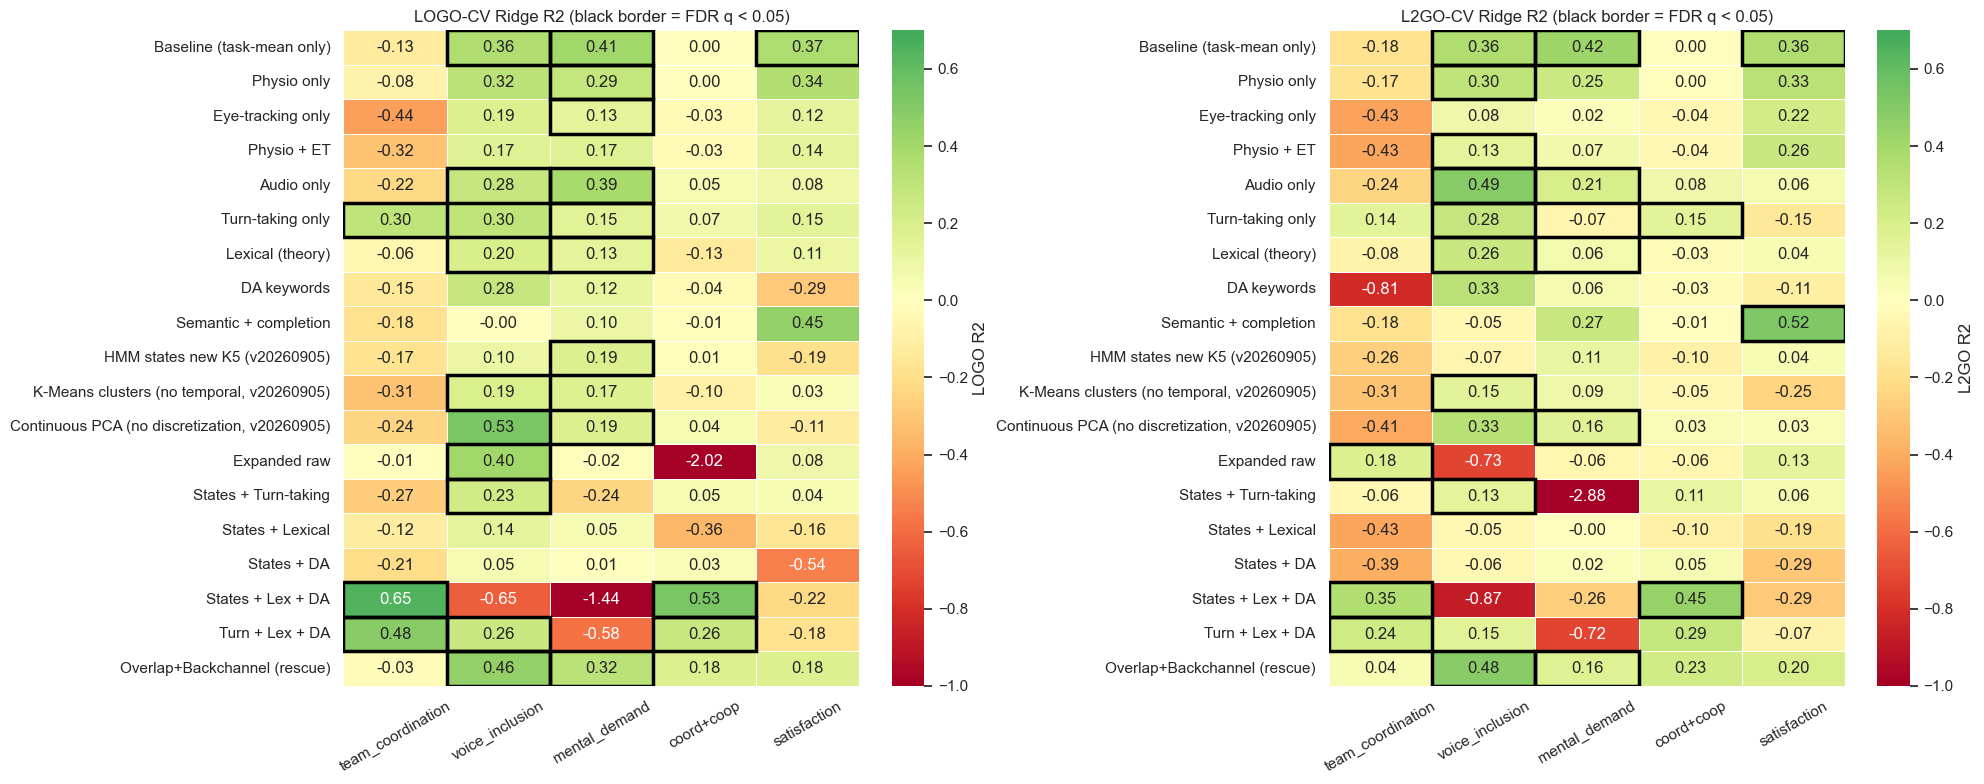

Uncorrected (p<0.05): LOGO=44/95  L2GO=46/95
FDR-corrected (q<0.05): LOGO=23/95  L2GO=21/95
FDR-significant in both: 15   only LOGO: 8   only L2GO: 6
Saved c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\prediction_r2_significance_v20260905.png

Baseline (task-mean only) rows:
  CV            Target     R2  n     p     q
LOGO team_coordination -0.130 20 0.327 0.398
LOGO   voice_inclusion  0.357 30 0.010 0.041
LOGO     mental_demand  0.410 30 0.010 0.041
LOGO        coord+coop  0.000 30 0.020 0.051
LOGO      satisfaction  0.368 20 0.010 0.041
L2GO team_coordination -0.177 20 0.644 0.737
L2GO   voice_inclusion  0.362 30 0.010 0.045
L2GO     mental_demand  0.422 30 0.010 0.045
L2GO        coord+coop  0.000 30 1.000 1.000
L2GO      satisfaction  0.356 20 0.010 0.045


In [20]:
row_order = list(MODALITY_SETS_FULL.keys())
col_order = list(TARGET_TASKS_FULL.keys())

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, cv_name in zip(axes, ['LOGO', 'L2GO']):
    sub = model_comp_full[model_comp_full['CV'] == cv_name]
    pivot_r2 = sub.pivot(index='Model', columns='Target', values='R2').reindex(index=row_order, columns=col_order)
    pivot_q  = sub.pivot(index='Model', columns='Target', values='q').reindex(index=row_order, columns=col_order)
    sns.heatmap(pivot_r2, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=0.7, linewidths=0.5, ax=ax, cbar_kws={'label': f'{cv_name} R2'})
    for yi, y_lbl in enumerate(pivot_r2.index):
        for xi, x_lbl in enumerate(pivot_r2.columns):
            q_val = pivot_q.loc[y_lbl, x_lbl]
            if pd.notna(q_val) and q_val < 0.05:
                ax.add_patch(plt.Rectangle((xi, yi), 1, 1, fill=False, edgecolor='black', linewidth=2.5))
    ax.set_title(f'{cv_name}-CV Ridge R2 (black border = FDR q < 0.05)')
    ax.set_ylabel(''); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
out_png = ANALYSIS_RES / 'prediction_r2_significance_v20260905.png'
plt.savefig(out_png, dpi=150)
plt.show()

pivot_p_logo = model_comp_full[model_comp_full['CV']=='LOGO'].pivot(index='Model', columns='Target', values='p').reindex(index=row_order, columns=col_order)
pivot_p_l2go = model_comp_full[model_comp_full['CV']=='L2GO'].pivot(index='Model', columns='Target', values='p').reindex(index=row_order, columns=col_order)
pivot_q_logo = model_comp_full[model_comp_full['CV']=='LOGO'].pivot(index='Model', columns='Target', values='q').reindex(index=row_order, columns=col_order)
pivot_q_l2go = model_comp_full[model_comp_full['CV']=='L2GO'].pivot(index='Model', columns='Target', values='q').reindex(index=row_order, columns=col_order)
sig_logo, sig_l2go = pivot_p_logo < 0.05, pivot_p_l2go < 0.05
fdr_logo, fdr_l2go = pivot_q_logo < 0.05, pivot_q_l2go < 0.05
print(f'Uncorrected (p<0.05): LOGO={int(sig_logo.sum().sum())}/{int(pivot_p_logo.notna().sum().sum())}'
      f'  L2GO={int(sig_l2go.sum().sum())}/{int(pivot_p_l2go.notna().sum().sum())}')
print(f'FDR-corrected (q<0.05): LOGO={int(fdr_logo.sum().sum())}/{int(pivot_q_logo.notna().sum().sum())}'
      f'  L2GO={int(fdr_l2go.sum().sum())}/{int(pivot_q_l2go.notna().sum().sum())}')
both      = (fdr_logo & fdr_l2go).sum().sum()
only_logo = (fdr_logo & ~fdr_l2go).sum().sum()
only_l2go = (~fdr_logo & fdr_l2go).sum().sum()
print(f'FDR-significant in both: {int(both)}   only LOGO: {int(only_logo)}   only L2GO: {int(only_l2go)}')
print(f'Saved {out_png}')

baseline = model_comp_full[model_comp_full['Model'] == 'Baseline (task-mean only)']
print('\nBaseline (task-mean only) rows:')
print(baseline[['CV', 'Target', 'R2', 'n', 'p', 'q']].to_string(index=False))


## 15. EDA — Self-Report Ratings by Task

Grounds the Section 14 finding that a trivial task-mean baseline beats every behavioral
feature set for `mental_demand`, `satisfaction`, `voice_inclusion`: shows how much of each
self-report outcome's variance is between-task vs. residual (left over for behavioral
features / models to explain), and plots the raw per-group ratings across tasks.


In [19]:
# How much of each self-report outcome's variance is explained by task alone?
sr_task_r2 = []
for col in SR_OUTCOMES:
    sub = sr.dropna(subset=[col])
    task_means = sub.groupby('task')[col].transform('mean')
    ss_between = ((task_means - sub[col].mean())**2).sum()
    ss_total = ((sub[col] - sub[col].mean())**2).sum()
    r2_task = ss_between / ss_total if ss_total > 0 else np.nan
    sr_task_r2.append(dict(outcome=col, n=len(sub), overall_sd=round(sub[col].std(), 3),
                            r2_task=round(r2_task, 3)))
sr_task_r2_df = pd.DataFrame(sr_task_r2)
print('Fraction of each self-report outcome\'s variance explained by task identity alone:')
print(sr_task_r2_df.to_string(index=False))


Fraction of each self-report outcome's variance explained by task identity alone:
                 outcome  n  overall_sd  r2_task
  team_coordination_mean 20       0.649    0.025
        cooperative_mean 10       0.621    0.000
    voice_inclusion_mean 30       0.782    0.476
      mental_demand_mean 30       0.957    0.520
       satisfaction_mean 20       0.747    0.488
decision_confidence_mean 10       0.755    0.000
       idea_quality_mean 10       0.845    0.000


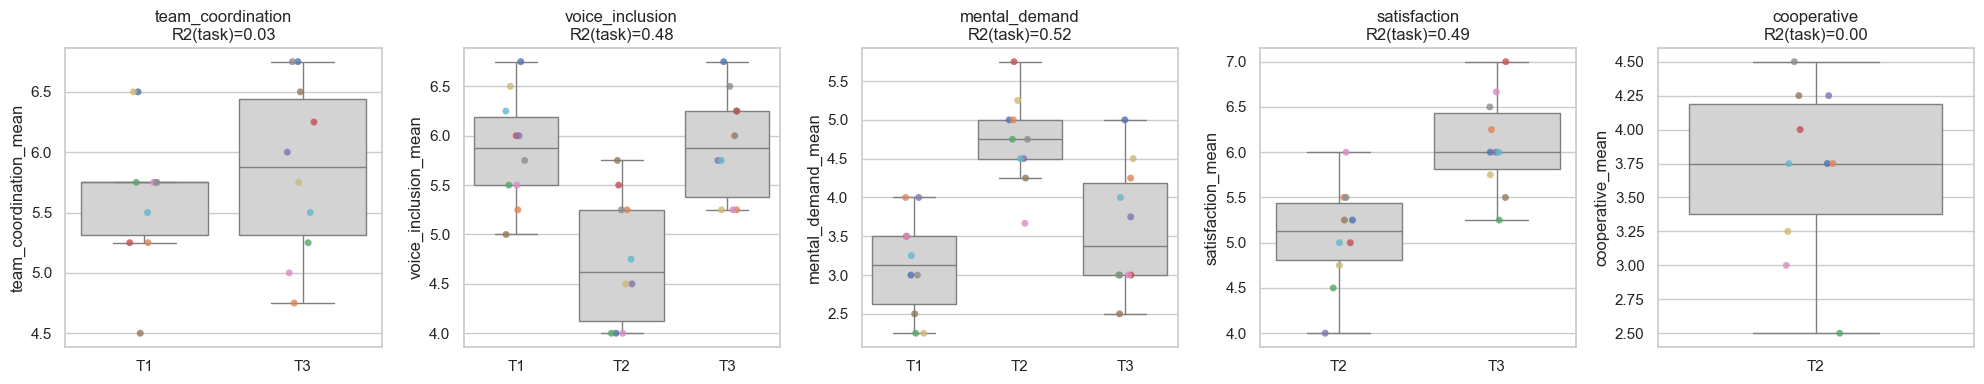

✓ Saved c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results/selfreport_by_task_v20260905.png


In [20]:
# Raw per-group self-report ratings across tasks -- visual companion to the table above
plot_outcomes = ['team_coordination_mean', 'voice_inclusion_mean', 'mental_demand_mean',
                 'satisfaction_mean', 'cooperative_mean']
plot_outcomes = [c for c in plot_outcomes if c in sr.columns]

fig, axes = plt.subplots(1, len(plot_outcomes), figsize=(4*len(plot_outcomes), 4), sharey=False)
for ax, col in zip(axes, plot_outcomes):
    sub = sr.dropna(subset=[col])
    order = sorted(sub['task'].unique())
    sns.boxplot(data=sub, x='task', y=col, order=order, ax=ax, color='lightgray', showfliers=False)
    sns.stripplot(data=sub, x='task', y=col, order=order, hue='group_id', ax=ax,
                  dodge=False, size=5, alpha=0.8, legend=False)
    r2 = sr_task_r2_df.loc[sr_task_r2_df['outcome'] == col, 'r2_task'].values[0]
    ax.set_title(f"{col.replace('_mean','')}\nR2(task)={r2:.2f}")
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(f'{ANALYSIS_RES}/selfreport_by_task_v20260905.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved {ANALYSIS_RES}/selfreport_by_task_v20260905.png')


## 16. Participant-Level Mixed-Effects Models

Section 15 showed task explains anywhere from ~0% to ~52% of self-report variance using group-task
means (n=10-30 rows). But the group-mean step also throws away real signal: participants disagree
meaningfully in their post-task ratings (e.g. one group's T1 voice-inclusion scores were
5.1/6.3/6.5/5.9 across P1-P4), and the raw per-participant answers behind every self-report outcome
used in this notebook already exist in the stimuli-answer files.

This section refits **all 7** viable self-report targets (not just the 2 with prior residual
signal) as participant-level mixed-effects models:

`individual rating ~ HMM state occupancy (group-level, shared across a group's participants) + task, random intercept for group_id`

Group-level predictors are unchanged (same `HMM_NEW_FEATS`, same preprocessing as Sections 11-15) --
only the *outcome* side is un-aggregated from ~1 row/group-task to ~4 rows/group-task (one per
participant). `group_id` is kept as the random-intercept/clustering unit throughout, since the
behavioral predictor is still only observed once per group-task. Significance is assessed with a
likelihood-ratio test against a task+group-intercept-only null model -- the correct test for
"do state features explain anything beyond task and each group's own average tendency."

In [22]:
import re

STIMULI_DIR = REPO_ROOT / 'metadata' / 'extracted stimuli answers'
STIM_GRP_RE = re.compile(r'ses-\d+_(grp-\d+)_run')
SR_ITEMS_PARTICIPANT = ['team_coordination', 'voice_inclusion', 'mental_demand',
                        'satisfaction', 'cooperative', 'decision_confidence', 'idea_quality']

sr_long_rows = []
for tsv in sorted(STIMULI_DIR.glob('*stimuli_answers_extracted.tsv')):
    m = STIM_GRP_RE.search(tsv.name)
    if m is None:
        continue
    grp = m.group(1)
    df = pd.read_csv(tsv, sep='\t', dtype=str)
    df.columns = df.columns.str.strip()
    for col in df.columns:
        df[col] = df[col].str.strip()
    df['item_value'] = pd.to_numeric(df['item_value'], errors='coerce')
    task_col = 'task' if 'task' in df.columns else 'task_id'
    sub = df[df['item_key'].isin(SR_ITEMS_PARTICIPANT)]
    for task in ['T1', 'T2', 'T3']:
        t_df = sub[sub[task_col] == task]
        for _, r in t_df.iterrows():
            sr_long_rows.append({'group_id': grp, 'task': task, 'participant': r['participant'],
                                  'item_key': r['item_key'], 'item_value': r['item_value']})

sr_long = pd.DataFrame(sr_long_rows)
sr_participant = (sr_long.pivot_table(index=['group_id', 'task', 'participant'],
                                       columns='item_key', values='item_value', aggfunc='mean')
                  .reset_index())
print(f'Participant-level self-report table: {sr_participant.shape} '
      f'({sr_participant["group_id"].nunique()} groups, incl. sessions outside the collective-features set)')
print(sr_participant[SR_ITEMS_PARTICIPANT].notna().sum())

Participant-level self-report table: (134, 10) (12 groups, incl. sessions outside the collective-features set)
item_key
team_coordination       88
voice_inclusion        134
mental_demand          133
satisfaction            89
cooperative             46
decision_confidence     44
idea_quality            44
dtype: int64


In [23]:
# Broadcast each group-task's behavioral features onto every participant's individual rating.
# Include every feature family used in the group-level ablation (Section 14), not just HMM/audio.
predictor_cols = (['group_id', 'task'] + HMM_FEATS + AUDIO_FEATS + HMM_OLD_FEATS
                  + HMM_NEW_FEATS + KMEANS_FEATS + PCA_CONT_FEATS
                  + PHYSIO + ET + TR_BASIC + EXTRA_TR_FEATS + OVL_TIMING_FEATS
                  + LEX_KEY_FEATS + KW_FEATS + SEM_FEATS + CR_FEATS + BERT_FEATS + NLI_FEATS)
predictor_cols = list(dict.fromkeys(c for c in predictor_cols if c in model_df.columns))
group_task_predictors = model_df[predictor_cols].drop_duplicates(subset=['group_id', 'task'])

participant_df = sr_participant.merge(group_task_predictors, on=['group_id', 'task'], how='inner')
print(f'Participant-level modeling table: {participant_df.shape}  '
      f'({participant_df["group_id"].nunique()} groups with behavioral features)')

Participant-level modeling table: (119, 92)  (10 groups with behavioral features)


In [35]:
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from statsmodels.regression.mixed_linear_model import MixedLM
from threadpoolctl import threadpool_limits


def fit_mixedlm_pair(df, outcome_col, feats, tasks, min_n=15, min_n_per_param=5):
    """LR-test: do state features add value over task + group/participant random effects?

    Participants are nested within groups and contribute multiple task-level
    observations (e.g. voice_inclusion/mental_demand: T1-T3), so a random intercept
    for group_id alone leaves the extra within-participant correlation across tasks
    unmodeled. A nested variance component for participant (unique per group via
    `group_id`+`participant`) is fit alongside the group_id random intercept in both
    the null and full model, so the LR test still isolates only the fixed-effect
    contribution. If the nested model fails to converge (small cluster sizes make the
    participant component weakly identified for some feature sets), both models fall
    back to the group-only random intercept and `nested_re=False` is returned so any
    degraded fits stay visible to callers instead of being silently reported as if
    fully nested.

    Also reports whether the full model raised a convergence warning and the
    n/parameter ratio for the full model, so callers can flag fits that are
    numerically unreliable or too overparameterized to trust the chi2 approximation.
    """
    sub = df[df['task'].isin(tasks)].copy()
    sub = sub.dropna(subset=[outcome_col] + feats)
    if sub['group_id'].nunique() < 3 or len(sub) < min_n:
        return None

    sub['participant_uid'] = sub['group_id'].astype(str) + '_' + sub['participant'].astype(str)

    task_dummies = pd.get_dummies(sub['task'], prefix='task', drop_first=True).astype(float)
    task_cols = [c for c in task_dummies.columns if task_dummies[c].nunique() > 1]
    sub = pd.concat([sub.reset_index(drop=True), task_dummies[task_cols].reset_index(drop=True)], axis=1)

    null_formula = f"{outcome_col} ~ " + (' + '.join(task_cols) if task_cols else '1')
    full_formula = f"{outcome_col} ~ " + ' + '.join(feats + task_cols)
    vc = {'participant': '0 + C(participant_uid)'}

    def _fit(formula, use_vc):
        # lbfgs fails on the final covariance inversion when a variance-component MLE is
        # near the zero boundary (common with small clusters); powell is more robust here,
        # but can still hit a singular boundary case, so fall back to nm/cg on failure.
        # Forcing single-threaded BLAS avoids run-to-run divergence at these boundary
        # cases caused by non-associative floating-point reduction order.
        last_exc = None
        with threadpool_limits(limits=1):
            for method in ('powell', 'nm', 'cg'):
                try:
                    # re_formula must be given explicitly once vc_formula is used, otherwise
                    # statsmodels drops the top-level group_id random intercept entirely.
                    mod = smf.mixedlm(formula, data=sub, groups='group_id',
                                       re_formula='1' if use_vc else None,
                                       vc_formula=vc if use_vc else None)
                    return mod.fit(reml=False, method=method)
                except Exception as exc:  # noqa: BLE001 - deliberately broad, we just try the next optimizer
                    last_exc = exc
        raise last_exc

    nested_re = True
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            m_null = _fit(null_formula, use_vc=True)
            m_full = _fit(full_formula, use_vc=True)
        conv_warnings = [str(w.message) for w in caught if 'onverg' in str(w.message).lower()]
    except Exception:
        # participant variance component not estimable at this cluster size for this
        # feature set -- fall back to the group-only random intercept, but keep it visible.
        nested_re = False
        print(f'  [{outcome_col}] nested participant RE not estimable, falling back to group-only intercept')
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                m_null = _fit(null_formula, use_vc=False)
                m_full = _fit(full_formula, use_vc=False)
            conv_warnings = [str(w.message) for w in caught if 'onverg' in str(w.message).lower()]
        except Exception as exc:
            print(f'  [{outcome_col}] MixedLM failed to converge (nested or group-only): {exc}')
            return None

    # No optimizer here exposes a reliable mle_retvals['converged'] flag across all three
    # fallback methods, so "no convergence warning raised" is the actual signal we have.
    converged = len(conv_warnings) == 0

    lr_stat = 2 * (m_full.llf - m_null.llf)
    k_fe_null = m_null.model.k_fe
    k_fe_full = m_full.model.k_fe
    dof = k_fe_full - k_fe_null
    lr_p = chi2.sf(lr_stat, dof) if dof > 0 else np.nan

    group_var = float(np.asarray(m_null.cov_re)[0, 0])
    participant_var = 0.0
    if nested_re:
        vc_names = list(m_null.model.exog_vc.names)
        vcomp_vals = np.asarray(m_null.vcomp)
        if 'participant' in vc_names:
            participant_var = float(vcomp_vals[vc_names.index('participant')])
    total_var = group_var + participant_var + m_null.scale
    icc = group_var / total_var if total_var > 0 else np.nan
    icc_participant = participant_var / total_var if total_var > 0 else np.nan

    coefs = m_full.fe_params
    pvals = m_full.pvalues.loc[coefs.index]

    # Rule-of-thumb heuristic (>=5 obs per fixed-effect parameter), not a formal power
    # calculation -- flags feature sets too large for n=~10 groups to fit reliably.
    n_per_param = round(len(sub) / k_fe_full, 2)

    return dict(
        n=len(sub), n_groups=sub['group_id'].nunique(), icc=round(icc, 3),
        icc_participant=round(icc_participant, 3) if not np.isnan(icc_participant) else np.nan,
        nested_re=nested_re,
        lr_stat=round(lr_stat, 2), dof=dof, lr_p=round(lr_p, 4),
        converged=converged, n_per_param=n_per_param,
        underpowered=n_per_param < min_n_per_param,
        feat_coefs={f: (round(coefs[f], 3), round(pvals[f], 4)) for f in feats},
    )


print('\u2713 fit_mixedlm_pair defined (nested participant-within-group random effect, '
      'group-only fallback flagged via nested_re)')

✓ fit_mixedlm_pair defined (nested participant-within-group random effect, group-only fallback flagged via nested_re)


In [36]:
# single-task targets (cooperative, decision_confidence, idea_quality) dropped:
# no within-target task variation for a single-task model, and cooperative is
# only meaningful as part of the multi-task composite.
TARGET_TASKS_PARTICIPANT = {
    'team_coordination':   (['T1', 'T3'],       'team_coordination'),
    'voice_inclusion':     (['T1', 'T2', 'T3'], 'voice_inclusion'),
    'mental_demand':       (['T1', 'T2', 'T3'], 'mental_demand'),
    'satisfaction':        (['T2', 'T3'],       'satisfaction'),
}

mixedlm_rows = []
coef_rows = []
for name, (tasks, col) in TARGET_TASKS_PARTICIPANT.items():
    old_n = sr[sr['task'].isin(tasks)][f'{name}_mean'].notna().sum() if f'{name}_mean' in sr.columns else np.nan
    # Drop one state (S4) as reference -- the 5 state proportions sum to 1 per row,
    # which is exactly collinear with the intercept in an unregularized MixedLM.
    res = fit_mixedlm_pair(participant_df, col, HMM_NEW_FEATS[:-1], tasks)
    if res is None:
        print(f'{name:20s}  skipped (insufficient participant-level data)')
        continue
    mixedlm_rows.append({
        'target': name, 'n_participant': res['n'], 'n_group_task_old': int(old_n),
        'n_groups': res['n_groups'], 'ICC': res['icc'],
        'LR_stat': res['lr_stat'], 'dof': res['dof'], 'LR_p': res['lr_p'],
    })
    for feat, (coef, p) in res['feat_coefs'].items():
        coef_rows.append({'target': name, 'feature': feat, 'coef': coef, 'p': p})

mixedlm_df = pd.DataFrame(mixedlm_rows).set_index('target')
print('=== Participant-level MixedLM: does HMM state occupancy add value beyond task + group intercept? ===')
print(mixedlm_df.to_string())

=== Participant-level MixedLM: does HMM state occupancy add value beyond task + group intercept? ===
                   n_participant  n_group_task_old  n_groups    ICC  LR_stat  dof    LR_p
target                                                                                   
team_coordination             72                20        10  0.016    13.66    5  0.0179
voice_inclusion              111                30        10  0.000     4.36    5  0.4982
mental_demand                110                30        10  0.000     4.16    5  0.5263
satisfaction                  75                20        10  0.000     1.71    5  0.8874


In [25]:
coef_df = pd.DataFrame(coef_rows)
sig = coef_df[coef_df['p'] < 0.10].sort_values(['target', 'p'])
print(f'\nHMM-state coefficients with p<0.10 ({len(sig)} of {len(coef_df)} target-feature pairs):')
print(sig.to_string(index=False) if not sig.empty else '(none -- no individual state feature reaches p<0.10 in any target)')


HMM-state coefficients with p<0.10 (1 of 20 target-feature pairs):
         target    feature   coef      p
voice_inclusion new_S1_pct -1.406 0.0437


## 16b. Participant-Level Mixed-Effects Ablation -- All Feature Sets x 4 Targets

Section 16 only tested HMM state occupancy, the weakest feature set in the group-level ablation (Section 14). Here the same participant-level MixedLM (task + group random intercept, LR-test) is repeated for every feature-set family from Section 14 -- physio, eye-tracking, audio, turn-taking, lexical, DA keywords, semantic/completion, K-Means, continuous PCA, and combinations -- restricted to the 4 targets with multi-task coverage (`team_coordination`, `voice_inclusion`, `mental_demand`, `satisfaction`).

All `_pct` state-proportion sets (HMM states, K-Means) drop one state as reference, same as Section 16, to avoid the exact collinearity with the intercept.

In [37]:
from statsmodels.stats.multitest import multipletests

HMM_NEW_FEATS_REF = HMM_NEW_FEATS[:-1]
KMEANS_FEATS_REF = KMEANS_FEATS[:-1] if len(KMEANS_FEATS) > 1 else KMEANS_FEATS

MODALITY_SETS_PARTICIPANT = {
    'Physio only':                   PHYSIO,
    'Eye-tracking only':             ET,
    'Physio + ET':                   PHYSIO + ET,
    'Audio only':                    AUDIO_FEATS,
    'Turn-taking only':              TURN_TAKING_FULL,
    'Lexical (theory)':              LEX_KEY_FEATS,
    'DA keywords':                   KW_FEATS,
    'Semantic + completion':         SEM_FEATS + CR_FEATS,
    'HMM states new K5 (v20260905)': HMM_NEW_FEATS_REF,
    'K-Means clusters (v20260905)':  KMEANS_FEATS_REF,
    'Continuous PCA (v20260905)':    PCA_CONT_FEATS,
    'Expanded raw':                  PHYSIO + ET + AUDIO_FEATS + TURN_TAKING_FULL,
    'States + Turn-taking':          HMM_NEW_FEATS_REF + TURN_TAKING_FULL,
    'States + Lexical':              HMM_NEW_FEATS_REF + LEX_KEY_FEATS,
    'States + DA':                   HMM_NEW_FEATS_REF + KW_FEATS,
    'States + Lex + DA':             HMM_NEW_FEATS_REF + LEX_KEY_FEATS + KW_FEATS,
    'Turn + Lex + DA':               TURN_TAKING_FULL + LEX_KEY_FEATS + KW_FEATS,
    'Overlap+Backchannel (rescue)':  ['tr_ovl_count', 'tr_backchannel_count'],
}

mlm_ablation_rows = []
for name, feats in MODALITY_SETS_PARTICIPANT.items():
    feats = [f for f in feats if f in participant_df.columns]
    if not feats:
        continue
    for target, (tasks, col) in TARGET_TASKS_PARTICIPANT.items():
        res = fit_mixedlm_pair(participant_df, col, feats, tasks)
        if res is None:
            continue
        mlm_ablation_rows.append({
            'feature_set': name, 'target': target, 'n_feats': len(feats),
            'n_participant': res['n'], 'n_groups': res['n_groups'], 'ICC': res['icc'],
            'LR_stat': res['lr_stat'], 'dof': res['dof'], 'LR_p': res['lr_p'],
        })

mlm_ablation_df = pd.DataFrame(mlm_ablation_rows)
mlm_ablation_df['q'] = np.nan
valid = mlm_ablation_df['LR_p'].notna()
mlm_ablation_df.loc[valid, 'q'] = multipletests(mlm_ablation_df.loc[valid, 'LR_p'], method='fdr_bh')[1].round(4)

n_sets = mlm_ablation_df['feature_set'].nunique()
n_targets = mlm_ablation_df['target'].nunique()
print(f'{len(mlm_ablation_df)} participant-level MixedLM fits ({n_sets} feature sets x {n_targets} targets)')
print(f'Uncorrected significant (p<0.05): {(mlm_ablation_df["LR_p"]<0.05).sum()}/{len(mlm_ablation_df)}')
print(f'FDR significant (q<0.05): {(mlm_ablation_df["q"]<0.05).sum()}/{len(mlm_ablation_df)}')
print()
print(mlm_ablation_df.sort_values('LR_p').to_string(index=False))

out_path = ANALYSIS_RES / 'participant_mixedlm_ablation_v20260907.tsv'
mlm_ablation_df.to_csv(out_path, sep='\t', index=False)
print(f'\nSaved {out_path}')

72 participant-level MixedLM fits (18 feature sets x 4 targets)
Uncorrected significant (p<0.05): 15/72
FDR significant (q<0.05): 0/72

                  feature_set            target  n_feats  n_participant  n_groups   ICC  LR_stat  dof   LR_p      q
             Turn-taking only team_coordination       13             72        10 0.016    30.60   13 0.0039 0.0926
             States + Lexical team_coordination       15             72        10 0.016    33.08   15 0.0046 0.0926
                  Physio only team_coordination        3             72        10 0.048    12.99    3 0.0047 0.0926
   Continuous PCA (v20260905) team_coordination       12             72        10 0.016    27.47   12 0.0066 0.0926
             Lexical (theory) team_coordination       10             72        10 0.016    24.12   10 0.0073 0.0926
 Overlap+Backchannel (rescue) team_coordination        2             72        10 0.016     9.66    2 0.0080 0.0926
                  States + DA team_coordination     

## 16c. Personality / Demographic Traits as Participant-Level Predictors

Every feature tested in 16/16b is a **group-level** feature (identical for every participant in a group-task), which structurally cannot explain within-group variance -- and Section 16b's near-zero ICC estimates show that's where almost all the variance in these ratings actually lives. Personality (BFI-44) and demographics are genuinely **participant-level** (they differ across P1-P4 within the same group), so they are the right kind of predictor to test against that within-group component.

Note: `TARGET_INVESTIGATION_LOG.md` §3 already tested BFI-44 traits with group-level Ridge CV against `perceived_effectiveness_z` and `team_coordination` and found them null (R² -0.03 to -0.06). This repeats the test properly at the participant level, with the current 4 multi-task targets, using the MixedLM/LR-test framework.

In [28]:
traits = pd.read_csv(ANALYSIS_RES / 'participant_traits.tsv', sep='\t')
BFI_FEATS = ['bfi44_e', 'bfi44_a', 'bfi44_c', 'bfi44_n', 'bfi44_o']

participant_df_traits = participant_df.merge(
    traits[['group_id', 'participant'] + BFI_FEATS + ['age']],
    on=['group_id', 'participant'], how='left')
print(f'Participant-level table with traits: {participant_df_traits.shape}  '
      f'({participant_df_traits[BFI_FEATS].notna().all(axis=1).sum()} rows with complete BFI-44)')

TRAIT_SETS = {
    'BFI-44 (5 traits)':      BFI_FEATS,
    'BFI-44 + age (6 feats)': BFI_FEATS + ['age'],
}

trait_rows = []
for name, feats in TRAIT_SETS.items():
    for target, (tasks, col) in TARGET_TASKS_PARTICIPANT.items():
        res = fit_mixedlm_pair(participant_df_traits, col, feats, tasks)
        if res is None:
            print(f'  [{name} / {target}]  skipped (insufficient data)')
            continue
        trait_rows.append({
            'feature_set': name, 'target': target, 'n_participant': res['n'],
            'n_groups': res['n_groups'], 'ICC': res['icc'],
            'LR_stat': res['lr_stat'], 'dof': res['dof'], 'LR_p': res['lr_p'],
            'feat_coefs': res['feat_coefs'],
        })

trait_df = pd.DataFrame(trait_rows)
print()
print('=== Participant-level MixedLM: do personality/demographic traits add value beyond '
      'task + group intercept? ===')
print(trait_df.drop(columns=['feat_coefs']).sort_values('LR_p').to_string(index=False))

print()
print('=== Per-trait coefficients (beta, p) for LR_p < 0.05 rows ===')
for _, row in trait_df[trait_df['LR_p'] < 0.05].sort_values('LR_p').iterrows():
    print(f"[{row['feature_set']} / {row['target']}]")
    for feat, (beta, p) in row['feat_coefs'].items():
        print(f'    {feat:10s}  beta={beta:+.3f}  p={p:.4f}')

Participant-level table with traits: (119, 98)  (119 rows with complete BFI-44)

=== Participant-level MixedLM: do personality/demographic traits add value beyond task + group intercept? ===
           feature_set            target  n_participant  n_groups  ICC  LR_stat  dof   LR_p
BFI-44 + age (6 feats)     mental_demand            118        10  0.0    14.17    6 0.0278
     BFI-44 (5 traits)     mental_demand            118        10  0.0    11.71    5 0.0391
     BFI-44 (5 traits)   voice_inclusion            119        10  0.0     4.76    5 0.4455
     BFI-44 (5 traits)      satisfaction             78        10  0.0     4.35    5 0.5002
BFI-44 + age (6 feats)   voice_inclusion            119        10  0.0     4.79    6 0.5712
     BFI-44 (5 traits) team_coordination             80        10  0.0     3.73    5 0.5884
BFI-44 + age (6 feats)      satisfaction             78        10  0.0     4.37    6 0.6265
BFI-44 + age (6 feats) team_coordination             80        10  0.0   

## 17. Focal vs. Others -- A Genuine Group-Interaction Design

Every prior section either (a) used group-level features (identical for all 4 participants -- can't explain within-group variance, Sections 14/16b) or (b) used participant-level traits that are *not* about the group interaction (Section 16c personality). This section tests the actual thesis question directly: **does what the other group members did/said predict a participant's own rating, beyond what they themselves did?**

Uses real per-participant behavioral features (not group means) from `analysis/results/participant_model_df.tsv` (built by `analysis/build_participant_df.py` from real per-speaker transcript/lexical/audio/physio/pupil extraction). For each (group, task, participant): `focal_*` = the participant's own feature values; `others_mean_*` / `others_std_*` = mean/std of the same features across the other 3 participants in that group-task.

**Methodology note:** an initial Ridge + label-permutation version of this test produced 96/132 'significant' univariate results -- but a diagnostic check showed a task-dummies-only baseline (zero behavioral features) hits the *same* p=0.005 floor. Global label permutation destroys the task-target relationship in the null but not the real fit, so it just re-detects the already-known task main effect, not any actual focal/others signal. Switched to the same MixedLM LR-test used in Sections 16/16c: full model (task + group intercept + focal/others features) vs. null model (task + group intercept only) -- this isolates genuine incremental value the same way as everywhere else in this notebook.

In [29]:
ptm = pd.read_csv(ANALYSIS_RES / 'participant_model_df.tsv', sep='\t')

FOCAL_CORE_FEATS = [
    'tr_speaking_time_s', 'tr_overlap_time_s', 'tr_backchannel_count',
    'lex_ttr', 'lex_sentiment_ratio', 'lex_agreement_rate',
    'audio_pitch_mean', 'audio_energy_mean',
    'hr_mean_bpm', 'eda_phasic_rate_hz', 'pupil_mean',
]
FOCAL_CORE_FEATS = [f for f in FOCAL_CORE_FEATS if f in ptm.columns]
print(f'{len(FOCAL_CORE_FEATS)} core per-participant features: {FOCAL_CORE_FEATS}')

focal_others_rows = []
for (grp, task), g in ptm.groupby(['group_id', 'task']):
    g = g.set_index('participant')
    parts = [p for p in ['P1', 'P2', 'P3', 'P4'] if p in g.index]
    if len(parts) < 2:
        continue
    for p in parts:
        others = g.loc[[o for o in parts if o != p], FOCAL_CORE_FEATS]
        row = {'group_id': grp, 'task': task, 'participant': p}
        for f in FOCAL_CORE_FEATS:
            row[f'focal_{f}'] = g.loc[p, f]
            row[f'others_mean_{f}'] = others[f].mean()
            row[f'others_std_{f}'] = others[f].std(ddof=0) if len(others) > 1 else np.nan
        focal_others_rows.append(row)

focal_others_df = pd.DataFrame(focal_others_rows)
print(f'Focal/others table: {focal_others_df.shape}')

11 core per-participant features: ['tr_speaking_time_s', 'tr_overlap_time_s', 'tr_backchannel_count', 'lex_ttr', 'lex_sentiment_ratio', 'lex_agreement_rate', 'audio_pitch_mean', 'audio_energy_mean', 'hr_mean_bpm', 'eda_phasic_rate_hz', 'pupil_mean']
Focal/others table: (120, 36)


In [30]:
fo_model_df = focal_others_df.merge(sr_participant, on=['group_id', 'task', 'participant'], how='inner')
print(f'Focal/others modeling table: {fo_model_df.shape}  '
      f'({fo_model_df["group_id"].nunique()} groups)')

# Note: task dummies are NOT pre-added here -- fit_mixedlm_pair computes them fresh
# internally from the 'task' column. Pre-adding them here would create duplicate
# task_* columns when fit_mixedlm_pair re-adds them, making the design matrix
# perfectly collinear (this previously caused every MixedLM fit to fail with
# 'Singular matrix', even single-feature univariate fits).
FO_TASK_DUMMY_COLS = list(pd.get_dummies(fo_model_df['task'], prefix='task', drop_first=True).columns)

FOCAL_COLS    = [f'focal_{f}'       for f in FOCAL_CORE_FEATS]
OTH_MEAN_COLS = [f'others_mean_{f}' for f in FOCAL_CORE_FEATS]
OTH_STD_COLS  = [f'others_std_{f}'  for f in FOCAL_CORE_FEATS]

FO_FEATURE_SETS = {
    'Focal only':              FOCAL_COLS,
    'Others mean only':        OTH_MEAN_COLS,
    'Others mean+std':         OTH_MEAN_COLS + OTH_STD_COLS,
    'Focal + Others mean':     FOCAL_COLS + OTH_MEAN_COLS,
    'Focal + Others mean+std': FOCAL_COLS + OTH_MEAN_COLS + OTH_STD_COLS,
}
print(f'{len(FO_FEATURE_SETS)} feature sets defined')

Focal/others modeling table: (119, 43)  (10 groups)
5 feature sets defined


In [31]:
fo_mlm_rows = []
for fs_name, feats in FO_FEATURE_SETS.items():
    for target, (tasks, col) in TARGET_TASKS_PARTICIPANT.items():
        res = fit_mixedlm_pair(fo_model_df, col, feats, tasks)
        if res is None:
            continue
        fo_mlm_rows.append({
            'feature_set': fs_name, 'target': target, 'n': res['n'],
            'n_groups': res['n_groups'], 'ICC': res['icc'],
            'LR_stat': res['lr_stat'], 'dof': res['dof'], 'LR_p': res['lr_p'],
            'n_per_param': res['n_per_param'], 'converged': res['converged'],
            'underpowered': res['underpowered'],
        })

fo_mlm_df = pd.DataFrame(fo_mlm_rows)
if fo_mlm_df.empty:
    print('(no valid MixedLM fits — all combinations failed to converge or had insufficient n)')
    fo_mlm_df['q'] = pd.Series(dtype=float)
    mask_p = pd.Series(dtype=bool)
else:
    fo_mlm_df['q'] = np.nan
    mask_p = fo_mlm_df['LR_p'].notna()
    fo_mlm_df.loc[mask_p, 'q'] = bh_fdr(fo_mlm_df.loc[mask_p, 'LR_p'].values).round(4)

if fo_mlm_df.empty:
    print('(fo_mlm_df is empty — nothing to report)')
else:
    n_sig = (fo_mlm_df['LR_p'] < 0.05).sum()
    n_fdr = (fo_mlm_df['q'] < 0.05).sum()
    n_unreliable = int((~fo_mlm_df['converged'] | fo_mlm_df['underpowered']).sum())
    print(f"Uncorrected significant (p<0.05): {n_sig}/{mask_p.sum()}")
    print(f"FDR significant (q<0.05): {n_fdr}/{mask_p.sum()}")
    print(f"Flagged non-converged or underpowered (n/param < 5): {n_unreliable}/{len(fo_mlm_df)}")
    print()
    print(fo_mlm_df.sort_values('LR_p').to_string(index=False))

out_tsv = ANALYSIS_RES / 'focal_others_mixedlm_ablation_v20260907.tsv'
fo_mlm_df.to_csv(out_tsv, sep='\t', index=False)
print(f'\nSaved {out_tsv}')

Uncorrected significant (p<0.05): 8/20
FDR significant (q<0.05): 2/20
Flagged non-converged or underpowered (n/param < 5): 14/20

            feature_set            target   n  n_groups   ICC  LR_stat  dof   LR_p  n_per_param  converged  underpowered      q
Focal + Others mean+std   voice_inclusion  95         9 0.000    63.63   33 0.0011         2.64       True          True 0.0220
Focal + Others mean+std team_coordination  62         9 0.014    59.98   33 0.0028         1.77       True          True 0.0280
    Focal + Others mean team_coordination  62         9 0.014    40.72   22 0.0089         2.58       True          True 0.0570
             Focal only   voice_inclusion  97        10 0.000    24.04   11 0.0126         6.93       True         False 0.0570
    Focal + Others mean   voice_inclusion  95         9 0.000    38.63   22 0.0156         3.80       True          True 0.0570
       Others mean only team_coordination  67        10 0.093    23.10   11 0.0171         5.15       

### 17b. Single-Feature Scan (Focal vs. Others-Mean vs. Others-Std)

Same MixedLM LR-test, one feature at a time -- more sensitive than the multi-feature sets above given only 10 groups. Tests whether *any single* focal or others feature adds value beyond task + group intercept.

In [32]:
scan_rows = []
for prefix, cols in [('focal', FOCAL_COLS), ('others_mean', OTH_MEAN_COLS), ('others_std', OTH_STD_COLS)]:
    for feat_col, base_feat in zip(cols, FOCAL_CORE_FEATS):
        for target, (tasks, col) in TARGET_TASKS_PARTICIPANT.items():
            res = fit_mixedlm_pair(fo_model_df, col, [feat_col], tasks)
            if res is None:
                continue
            scan_rows.append({
                'kind': prefix, 'feature': base_feat, 'target': target, 'n': res['n'],
                'ICC': res['icc'], 'LR_stat': res['lr_stat'], 'dof': res['dof'], 'LR_p': res['lr_p'],
                'n_per_param': res['n_per_param'], 'converged': res['converged'],
                'underpowered': res['underpowered'],
            })

scan_df = pd.DataFrame(scan_rows)
if scan_df.empty:
    print('(no valid MixedLM fits — all combinations failed to converge or had insufficient n)')
    scan_df['q'] = pd.Series(dtype=float)
    mask_p = pd.Series(dtype=bool)
else:
    scan_df['q'] = np.nan
    mask_p = scan_df['LR_p'].notna()
    scan_df.loc[mask_p, 'q'] = bh_fdr(scan_df.loc[mask_p, 'LR_p'].values).round(4)

if scan_df.empty:
    print('(scan_df is empty — nothing to report)')
else:
    n_sig = (scan_df['LR_p'] < 0.05).sum()
    n_fdr = (scan_df['q'] < 0.05).sum()
    n_unreliable = int((~scan_df['converged'] | scan_df['underpowered']).sum())
    print(f"Uncorrected significant (p<0.05): {n_sig}/{mask_p.sum()}")
    print(f"FDR significant (q<0.05): {n_fdr}/{mask_p.sum()}")
    print(f"Flagged non-converged or underpowered (n/param < 5): {n_unreliable}/{len(scan_df)}")
    print()
    sig = scan_df[scan_df['LR_p'] < 0.05].sort_values('LR_p')
    print(sig.to_string(index=False) if not sig.empty
          else '(no single focal/others feature reaches p<0.05 for any target)')

out_tsv = ANALYSIS_RES / 'focal_others_univariate_scan_v20260907.tsv'
scan_df.to_csv(out_tsv, sep='\t', index=False)
print(f'\nSaved {out_tsv}')

Uncorrected significant (p<0.05): 14/132
FDR significant (q<0.05): 0/132
Flagged non-converged or underpowered (n/param < 5): 0/132

       kind              feature            target   n   ICC  LR_stat  dof   LR_p  n_per_param  converged  underpowered      q
others_mean   eda_phasic_rate_hz team_coordination  71 0.084     9.30    1 0.0023        23.67       True         False 0.1760
      focal tr_backchannel_count   voice_inclusion 111 0.000     8.75    1 0.0031        27.75       True         False 0.1760
      focal  lex_sentiment_ratio team_coordination  72 0.016     8.30    1 0.0040        24.00       True         False 0.1760
      focal              lex_ttr   voice_inclusion 111 0.000     6.85    1 0.0089        27.75       True         False 0.2937
      focal   tr_speaking_time_s   voice_inclusion 111 0.000     5.17    1 0.0230        27.75       True         False 0.4224
 others_std           pupil_mean     mental_demand 118 0.000     4.76    1 0.0292        29.50       True

### 17c. Pre-registered confirmatory pair (H2 extension, voice_inclusion)

Two single hypotheses, chosen before looking at target-specific results (the univariate scan above was already run, so we only use it to confirm these were not already peeked at as the top hit for this target):

1. `others_mean_eda_phasic_rate_hz -> voice_inclusion` -- shared arousal/engagement in the rest of the group signals a livelier, more inclusive discussion.
2. `others_mean_tr_backchannel_count -> voice_inclusion` -- others backchanneling more (active-listening cues) should make the focal participant feel heard.

BH-FDR correction applied only across this pair (not pooled with the exploratory scan).

In [33]:
confirm_feats = [
    'others_mean_eda_phasic_rate_hz',
    'others_mean_tr_backchannel_count',
    'others_mean_lex_agreement_rate',
    'others_mean_tr_overlap_time_s',
]

tasks, col = TARGET_TASKS_PARTICIPANT['voice_inclusion']

confirm_rows = []
for feat_col in confirm_feats:
    res = fit_mixedlm_pair(fo_model_df, col, [feat_col], tasks)
    if res is None:
        print(f'{feat_col:35s}  skipped (insufficient data)')
        continue
    coef, p = res['feat_coefs'][feat_col]
    confirm_rows.append({
        'hypothesis': feat_col, 'target': 'voice_inclusion', 'n': res['n'],
        'n_groups': res['n_groups'], 'coef': coef, 'LR_p': res['lr_p'],
        'n_per_param': res['n_per_param'], 'converged': res['converged'],
        'underpowered': res['underpowered'],
    })

confirm_df = pd.DataFrame(confirm_rows)
if not confirm_df.empty:
    confirm_df['q'] = bh_fdr(confirm_df['LR_p'].values).round(4)
print(confirm_df.to_string(index=False))

out_tsv = ANALYSIS_RES / 'focal_others_confirmatory_pair_v20260908.tsv'
confirm_df.to_csv(out_tsv, sep='\t', index=False)
print(f'\nSaved {out_tsv}')


                      hypothesis          target   n  n_groups   coef   LR_p  n_per_param  converged  underpowered      q
  others_mean_eda_phasic_rate_hz voice_inclusion 109        10 -0.215 0.9329        27.25       True         False 0.9329
others_mean_tr_backchannel_count voice_inclusion 111        10  0.014 0.6752        27.75       True         False 0.9003
  others_mean_lex_agreement_rate voice_inclusion 111        10  3.100 0.6372        27.75       True         False 0.9003
   others_mean_tr_overlap_time_s voice_inclusion 111        10  0.011 0.4797        27.75       True         False 0.9003

Saved c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\focal_others_confirmatory_pair_v20260908.tsv


## 18. Higher-resolution significance + bootstrap CI for the two headline findings

`Section 14`'s ablation used only 100 permutations (floor p=1/101≈0.0099) and a single point-estimate R²
per CV scheme, so several "p=0.01" rows are really just "below the resolution of 100 permutations", and
we have no sense of how much the R² estimate would vary under resampling with only ~18-28 group-task
rows. This section re-tests the two most defensible findings from Section 14 with 2000 permutations and
a group-level bootstrap CI on R² (resampling groups with replacement, then rebuilding LOGO/L2GO folds on
the resampled data) — directly following the thesis's stated principle of reporting performance
distributions/CIs rather than a single optimistic R².

**Feature definitions** (per `docs/feature_catalog.md` §4, group-task-level rollups of the participant
transcript annotation):
- `tr_ovl_count` — count of `OVL` (overlap) events: instances of 2+ simultaneous speakers.
- `tr_backchannel_count` — count of `BCK` (backchannel) events: short supportive interjections (e.g. "mm-hmm").
- `tr_silence_duration_s`, `tr_laughter_count`, `tr_n_active_speakers` — silence time, laughter count,
  number of distinct speakers active in the task.
- `tr_ovl_time_s` — total overlap duration (s).
- `tr_speaking_entropy` — Shannon entropy of speaking-time distribution across participants (higher =
  more evenly shared floor time).
- `tr_spk_count` — total number of speaking-turn segments.
- `tr_ovl_simultaneous` / `tr_ovl_smooth` / `tr_ovl_competitive_timing` / `tr_ovl_floor_fight` — overlap
  subtype counts (cooperative vs. competitive timing classes).
- `tr_conflict_overlap_ratio` — competitive / (competitive + cooperative) overlap ratio.

In [33]:
from sklearn.model_selection import GroupKFold as _GroupKFold

def group_bootstrap_r2(feature_cols, target_col, task_filter, cv_kind, n_boot=1000, seed=0):
    """Bootstrap CI on cross-validated R2 by resampling group_id's with replacement,
    rebuilding LOGO/L2GO folds on the resampled data each time (duplicated groups are
    relabeled so they don't collapse into a single fold)."""
    df = model_df[model_df['task'].isin(task_filter)].copy()
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    avail_feats = [c for c in feature_cols if c in df.columns]
    cols = avail_feats + task_cols
    X_full = df[cols].values.astype(float)
    y_full = df[target_col].values.astype(float)
    g_full = df['group_id'].values
    mask = ~(np.isnan(X_full).any(axis=1) | np.isnan(y_full))
    X_m, y_m, g_m = X_full[mask], y_full[mask], g_full[mask]
    groups_unique = np.unique(g_m)

    rng = np.random.default_rng(seed)
    r2s = []
    for _ in range(n_boot):
        sampled_groups = rng.choice(groups_unique, size=len(groups_unique), replace=True)
        idx_parts, new_groups = [], []
        for i, gid in enumerate(sampled_groups):
            idx = np.where(g_m == gid)[0]
            idx_parts.append(idx)
            new_groups.extend([i] * len(idx))
        idx_all = np.concatenate(idx_parts)
        X_b, y_b, g_b = X_m[idx_all], y_m[idx_all], np.array(new_groups)
        n_unique = len(np.unique(g_b))
        if n_unique < 3:
            continue
        cv = LeaveOneGroupOut() if cv_kind == 'LOGO' else _GroupKFold(n_splits=min(5, n_unique))
        pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
        try:
            preds = cross_val_predict(pipe, X_b, y_b, cv=cv, groups=g_b)
            r2s.append(r2_score(y_b, preds))
        except Exception:
            continue
    return np.array(r2s)

HIGH_RES_TARGETS = [
    ('Overlap+Backchannel (rescue)', ['tr_ovl_count', 'tr_backchannel_count'],
     ['T1', 'T2', 'T3'], 'voice_inclusion_mean', 'voice_inclusion'),
    ('Turn-taking only', TURN_TAKING_FULL,
     ['T1', 'T3'], 'team_coordination_mean', 'team_coordination'),
]

high_res_rows = []
for model_name, feats, tasks, t_col, t_name in HIGH_RES_TARGETS:
    for cv_name, cv in [('LOGO', LOGO), ('L2GO', L2GO)]:
        res = ridge_ablation(feats, t_col, tasks, cv, n_perm=2000, seed=42)
        boot_r2 = group_bootstrap_r2(feats, t_col, tasks, cv_name, n_boot=1000, seed=42)
        ci_lo, ci_hi = (np.percentile(boot_r2, [2.5, 97.5]) if len(boot_r2) > 0 else (np.nan, np.nan))
        high_res_rows.append({
            'Model': model_name, 'Target': t_name, 'CV': cv_name,
            'R2': res['R2'], 'n': res['n'], 'p_2000perm': res['p'],
            'boot_ci_2.5%': round(float(ci_lo), 3), 'boot_ci_97.5%': round(float(ci_hi), 3),
            'n_boot_valid': len(boot_r2),
        })
        print(f"{model_name} -> {t_name} ({cv_name}): R2={res['R2']} p(2000 perm)={res['p']} "
              f"95% bootstrap CI=[{ci_lo:.3f}, {ci_hi:.3f}] (n_boot={len(boot_r2)})")

high_res_df = pd.DataFrame(high_res_rows)
out_tsv = ANALYSIS_RES / 'headline_findings_highres_v20260908.tsv'
high_res_df.to_csv(out_tsv, sep='\t', index=False)
print(f'\nSaved {out_tsv}')
print()
print(high_res_df.to_string(index=False))

Overlap+Backchannel (rescue) -> voice_inclusion (LOGO): R2=0.459 p(2000 perm)=0.001 95% bootstrap CI=[0.201, 0.769] (n_boot=1000)
Overlap+Backchannel (rescue) -> voice_inclusion (L2GO): R2=0.483 p(2000 perm)=0.001 95% bootstrap CI=[0.095, 0.769] (n_boot=1000)
Turn-taking only -> team_coordination (LOGO): R2=0.296 p(2000 perm)=0.007 95% bootstrap CI=[-0.462, 0.959] (n_boot=1000)
Turn-taking only -> team_coordination (L2GO): R2=0.144 p(2000 perm)=0.017 95% bootstrap CI=[-0.642, 0.938] (n_boot=1000)

Saved c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\headline_findings_highres_v20260908.tsv

                       Model            Target   CV    R2  n  p_2000perm  boot_ci_2.5%  boot_ci_97.5%  n_boot_valid
Overlap+Backchannel (rescue)   voice_inclusion LOGO 0.459 28       0.001         0.201          0.769          1000
Overlap+Backchannel (rescue)   voice_inclusion L2GO 0.483 28       0.001         0.095          0.769          1000
  

**Interpretation:** if the 95% bootstrap CI for a given model/target/CV combination excludes 0, that
is much stronger evidence than a single "p=0.01" from only 100 permutations. If the CI is wide and
straddles 0 despite a positive point-estimate R², that specific result should be treated as suggestive,
not confirmatory, given n≈18-28.

## 18b. Collinearity / construct-validity check for the `voice_inclusion` headline finding

Before treating `tr_ovl_count` (overlap-event count) and `tr_backchannel_count` (backchannel-event
count) as two independent conversation-structure signals, check (a) whether they are redundant with
each other, (b) whether either is just a proxy for how much a group talked overall (`tr_silence_duration_s`,
`tr_n_active_speakers`), and (c) whether the two-feature model's effect is driven by one dominant
feature or genuinely needs both.

In [34]:
voi_tasks = ['T1', 'T2', 'T3']
voi_df = model_df[model_df['task'].isin(voi_tasks)].copy()

corr_feats = ['tr_ovl_count', 'tr_backchannel_count', 'tr_silence_duration_s',
              'tr_n_active_speakers', 'tr_ovl_time_s', 'tr_laughter_count']
corr_feats = [c for c in corr_feats if c in voi_df.columns]
corr = voi_df[corr_feats].corr(method='pearson').round(3)
print('Pearson correlation matrix (voice_inclusion task subset, n =', len(voi_df), 'rows):')
print(corr.to_string())

print()
print('--- Single-feature R2 for voice_inclusion (task dummies + one feature at a time) ---')
for feat in ['tr_ovl_count', 'tr_backchannel_count']:
    for cv_name, cv in [('LOGO', LOGO), ('L2GO', L2GO)]:
        res = ridge_ablation([feat], 'voice_inclusion_mean', voi_tasks, cv, n_perm=2000, seed=42)
        print(f"{feat} alone ({cv_name}): R2={res['R2']} n={res['n']} p={res['p']}")

print()
print('--- Both features together (for comparison, same as headline finding) ---')
for cv_name, cv in [('LOGO', LOGO), ('L2GO', L2GO)]:
    res = ridge_ablation(['tr_ovl_count', 'tr_backchannel_count'], 'voice_inclusion_mean', voi_tasks, cv, n_perm=2000, seed=42)
    print(f"both ({cv_name}): R2={res['R2']} n={res['n']} p={res['p']}")

Pearson correlation matrix (voice_inclusion task subset, n = 30 rows):
                       tr_ovl_count  tr_backchannel_count  tr_silence_duration_s  tr_n_active_speakers  tr_ovl_time_s  tr_laughter_count
tr_ovl_count                  1.000                 0.200                  0.182                 0.593          0.884              0.462
tr_backchannel_count          0.200                 1.000                 -0.172                 0.369          0.088              0.570
tr_silence_duration_s         0.182                -0.172                  1.000                 0.281         -0.083              0.214
tr_n_active_speakers          0.593                 0.369                  0.281                 1.000          0.373              0.663
tr_ovl_time_s                 0.884                 0.088                 -0.083                 0.373          1.000              0.263
tr_laughter_count             0.462                 0.570                  0.214                 0.663     

**Interpretation:** if `tr_ovl_count` and `tr_backchannel_count` correlate only weakly with each
other and with `tr_silence_duration_s`/`tr_n_active_speakers` (the "how much did they talk overall"
proxies), the two-feature model reflects genuine, non-redundant conversation-structure signal rather
than a single talkativeness confound. If the single-feature R2's are each substantially below the
two-feature R2, both features are contributing independently rather than one carrying the result.

## 19. Single-feature scan for `team_coordination` and `coord+coop` (dimensionality-reduction rescue)

For `voice_inclusion`, dropping from the full 13-feature `Turn-taking only` set down to just 2 features
(`Overlap+Backchannel`) *improved* R2 and gave a bootstrap CI excluding 0 — the full set was diluting a
strong signal with noise features on a small n. Test whether the same rescue works for
`team_coordination` (whose 13-feature CI straddled 0) and for the `coord+coop` composite, by scanning
each of the 13 `TURN_TAKING_FULL` features individually, then testing the best-supported small
combination with the same high-resolution permutation + bootstrap-CI treatment as `Section 18`.

In [35]:
from itertools import combinations

SCAN_TARGETS = [
    ('team_coord', ['T1', 'T3'], 'team_coordination_mean'),
    ('coord+coop (centered)', ['T1', 'T2', 'T3'], '_coord_coop_centered'),
]

scan_rows = []
for t_name, tasks, t_col in SCAN_TARGETS:
    for feat in TURN_TAKING_FULL:
        for cv_name, cv in [('LOGO', LOGO), ('L2GO', L2GO)]:
            res = ridge_ablation([feat], t_col, tasks, cv, n_perm=500, seed=42)
            scan_rows.append({'Target': t_name, 'Feature': feat, 'CV': cv_name,
                               'R2': res['R2'], 'n': res['n'], 'p': res['p']})

scan_df = pd.DataFrame(scan_rows)
# FDR-correct within each (target, CV) family across the 13 features
scan_df['q'] = np.nan
for (t_name, cv_name), idx in scan_df.groupby(['Target', 'CV']).groups.items():
    scan_df.loc[idx, 'q'] = bh_fdr(scan_df.loc[idx, 'p'].values)

out_tsv = ANALYSIS_RES / 'turn_taking_single_feature_scan_v20260908.tsv'
scan_df.sort_values(['Target', 'CV', 'q']).to_csv(out_tsv, sep='\t', index=False)
print(f'Saved {out_tsv}')
print()
for t_name in scan_df['Target'].unique():
    print(f'--- {t_name}: features with nominal p<0.10 (either CV) ---')
    sub = scan_df[(scan_df['Target'] == t_name) & (scan_df['p'] < 0.10)]
    print(sub.sort_values(['CV', 'p'])[['CV', 'Feature', 'R2', 'n', 'p', 'q']].to_string(index=False))
    print()

Saved c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\turn_taking_single_feature_scan_v20260908.tsv

--- team_coord: features with nominal p<0.10 (either CV) ---
  CV                   Feature     R2  n     p        q
L2GO             tr_ovl_time_s  0.156 18 0.008 0.065000
L2GO tr_ovl_competitive_timing  0.272 18 0.010 0.065000
L2GO              tr_ovl_count  0.016 18 0.038 0.164667
LOGO tr_ovl_competitive_timing  0.224 18 0.010 0.130000
LOGO             tr_ovl_time_s -0.056 18 0.052 0.294667
LOGO              tr_ovl_count -0.020 18 0.068 0.294667

--- coord+coop (centered): features with nominal p<0.10 (either CV) ---
  CV                   Feature     R2  n     p     q
L2GO             tr_ovl_time_s  0.023 28 0.032 0.325
L2GO              tr_ovl_count  0.025 28 0.050 0.325
LOGO tr_ovl_competitive_timing -0.021 28 0.068 0.598
LOGO              tr_ovl_count -0.063 28 0.092 0.598



### 19b. Test the best-supported small combinations with high-resolution permutation + bootstrap CI

In [36]:
RESCUE_CANDIDATES = [
    ('team_coord', ['T1', 'T3'], 'team_coordination_mean', 'team_coordination'),
    ('coord+coop (centered)', ['T1', 'T2', 'T3'], '_coord_coop_centered', 'coord+coop'),
]

rescue_rows = []
for scan_target, tasks, t_col, t_name in RESCUE_CANDIDATES:
    sub = scan_df[scan_df['Target'] == scan_target]
    # candidate small combo: features nominally significant (p<0.10) in at least one CV scheme
    cand_feats = sub[sub['p'] < 0.10]['Feature'].unique().tolist()
    if len(cand_feats) == 0:
        print(f'{t_name}: no candidate features with p<0.10, skipping rescue test')
        continue
    if len(cand_feats) > 4:
        # keep the 4 with the lowest mean p across CV schemes
        mean_p = sub[sub['Feature'].isin(cand_feats)].groupby('Feature')['p'].mean().sort_values()
        cand_feats = mean_p.head(4).index.tolist()
    print(f'{t_name}: candidate rescue feature set = {cand_feats}')
    for cv_name, cv in [('LOGO', LOGO), ('L2GO', L2GO)]:
        res = ridge_ablation(cand_feats, t_col, tasks, cv, n_perm=2000, seed=42)
        boot_r2 = group_bootstrap_r2(cand_feats, t_col, tasks, cv_name, n_boot=1000, seed=42)
        ci_lo, ci_hi = (np.percentile(boot_r2, [2.5, 97.5]) if len(boot_r2) > 0 else (np.nan, np.nan))
        rescue_rows.append({
            'Target': t_name, 'Features': ', '.join(cand_feats), 'CV': cv_name,
            'R2': res['R2'], 'n': res['n'], 'p_2000perm': res['p'],
            'boot_ci_2.5%': round(float(ci_lo), 3), 'boot_ci_97.5%': round(float(ci_hi), 3),
        })
        print(f"  {cv_name}: R2={res['R2']} p={res['p']} 95% bootstrap CI=[{ci_lo:.3f}, {ci_hi:.3f}]")

rescue_df = pd.DataFrame(rescue_rows)
out_tsv2 = ANALYSIS_RES / 'team_coord_coopcoop_rescue_v20260908.tsv'
rescue_df.to_csv(out_tsv2, sep='\t', index=False)
print(f'\nSaved {out_tsv2}')
print()
print(rescue_df.to_string(index=False))

team_coordination: candidate rescue feature set = ['tr_ovl_count', 'tr_ovl_time_s', 'tr_ovl_competitive_timing']
  LOGO: R2=0.233 p=0.015 95% bootstrap CI=[-0.741, 0.686]
  L2GO: R2=0.242 p=0.012 95% bootstrap CI=[-0.920, 0.681]
coord+coop: candidate rescue feature set = ['tr_ovl_count', 'tr_ovl_time_s', 'tr_ovl_competitive_timing']
  LOGO: R2=0.066 p=0.031 95% bootstrap CI=[-0.279, 0.558]
  L2GO: R2=0.073 p=0.022 95% bootstrap CI=[-0.414, 0.547]

Saved c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\team_coord_coopcoop_rescue_v20260908.tsv

           Target                                               Features   CV    R2  n  p_2000perm  boot_ci_2.5%  boot_ci_97.5%
team_coordination tr_ovl_count, tr_ovl_time_s, tr_ovl_competitive_timing LOGO 0.233 18       0.015        -0.741          0.686
team_coordination tr_ovl_count, tr_ovl_time_s, tr_ovl_competitive_timing L2GO 0.242 18       0.012        -0.920          0.681
       coord+coo

**Interpretation:** if the rescue combination's bootstrap CI excludes 0 (as it did for
`voice_inclusion`'s `Overlap+Backchannel` pair), that gives `team_coordination` a robust
finding to replace the unstable 13-feature `Turn-taking only` result. If the CI still straddles 0, the
13-feature instability was likely a genuine small-effect/small-n issue rather than pure feature-set
dilution, and `team_coordination`/`coord+coop` should stay framed as suggestive, not confirmatory.